# Simulation results analysis

Reads `combined_simulations.csv` and produces:

1. Corrected `max` and `MPM` values (subtract the mean, **not** absolute).
2. Per Hs: 6 subplots (3 DOFs × {MPM, Std}) averaged over wave directions, one line per damping case.
3. Per Hs: 6 subplots of the **percentage difference vs. the `low` case** (3 lines per subplot).
4. Per DOF: the most extreme MPM observed across directions, plotted vs Tp for every damping case.

Direction filter: pitch ignores 90°, roll ignores 0° and 180°.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

## 1. Load and correct the data

In [9]:
df = pd.read_csv('Simulation_output_redo.csv')

# Rename DOFbest -> average
for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    df[col] = df[col].replace({'DOFbest': 'average'})

# Correct max and MPM by subtracting the mean (signed, NOT absolute).
# For amplitude vs. mean offset we still want a positive magnitude, so take |signal - mean|.
for dof, suffix in [('Z', 'Z'), ('pitch', 'pitch'), ('roll', 'roll')]:
    
    df[f'MPM {suffix} corr'] = (df[f'MPM {suffix}'] - df[f'Mean {suffix}']).abs()

df.head()

,filename,Hs,Tp,Tz,Direction,Damp_Heave,Damp_Roll,Damp_Pitch,Lin_Heave,Quad_Heave,...,Std roll,Mean Z,Mean pitch,Mean roll,MPM Z,MPM pitch,MPM roll,MPM Z corr,MPM pitch corr,MPM roll corr
0,ymlfiles\Case_001_H1_T3p5_dir0_heavelow_pitchl...,1,3.5,2.7132,0,low,low,low,1.0,1.0,...,0.000173,-0.155893,0.684405,-0.002331,-0.095942,3.390856,-0.001673,0.059950,2.706451,0.000658
1,ymlfiles\Case_002_H1_T3p5_dir0_heavelinhigh_pi...,1,3.5,2.7132,0,linhigh,linhigh,linhigh,6.5,1.0,...,0.000158,-0.155882,0.684157,-0.002331,-0.097238,3.379648,-0.001730,0.058644,2.695492,0.000602
2,ymlfiles\Case_003_H1_T3p5_dir0_heavequadhigh_p...,1,3.5,2.7132,0,quadhigh,quadhigh,quadhigh,1.0,4.0,...,0.000173,-0.155892,0.684348,-0.002331,-0.095931,3.388490,-0.001674,0.059962,2.704141,0.000657
3,ymlfiles\Case_004_H1_T3p5_dir0_heaveDOFbest_pi...,1,3.5,2.7132,0,average,average,average,3.3,2.4,...,0.000162,-0.155889,0.684243,-0.002331,-0.096463,3.383665,-0.001712,0.059426,2.699423,0.000619
4,ymlfiles\Case_005_H1_T3p5_dir45_heavelow_pitch...,1,3.5,2.7132,45,low,low,low,1.0,1.0,...,0.351683,-0.155533,0.675667,0.004330,-0.109827,1.920572,1.411232,0.045706,1.244906,1.406902


In [10]:
# DOF setup: column suffix, display name, directions to drop
DOFS = [
    {'key': 'Z',     'name': 'Heave', 'unit': 'm',   'drop_dirs': []},
    {'key': 'pitch', 'name': 'Pitch', 'unit': 'deg', 'drop_dirs': []},
    {'key': 'roll',  'name': 'Roll',  'unit': 'deg', 'drop_dirs': []},
]

# Damping cases (each row uses the same value for Heave/Roll/Pitch in this dataset)
DAMPING_CASES = ['low', 'linhigh', 'quadhigh', 'average']
DAMPING_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'average':  '#d62728',
}

HS_VALUES = sorted(df['Hs'].unique())
print('Hs values:', HS_VALUES)

Hs values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]


In [11]:
def filter_dirs(sub, dof):
    """Drop directions that are physically not excited for the given DOF."""
    if dof['drop_dirs']:
        sub = sub[~sub['Direction'].isin(dof['drop_dirs'])]
    return sub

def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

## 2. MPM and Std vs Tp, averaged over directions (6 subplots per Hs)

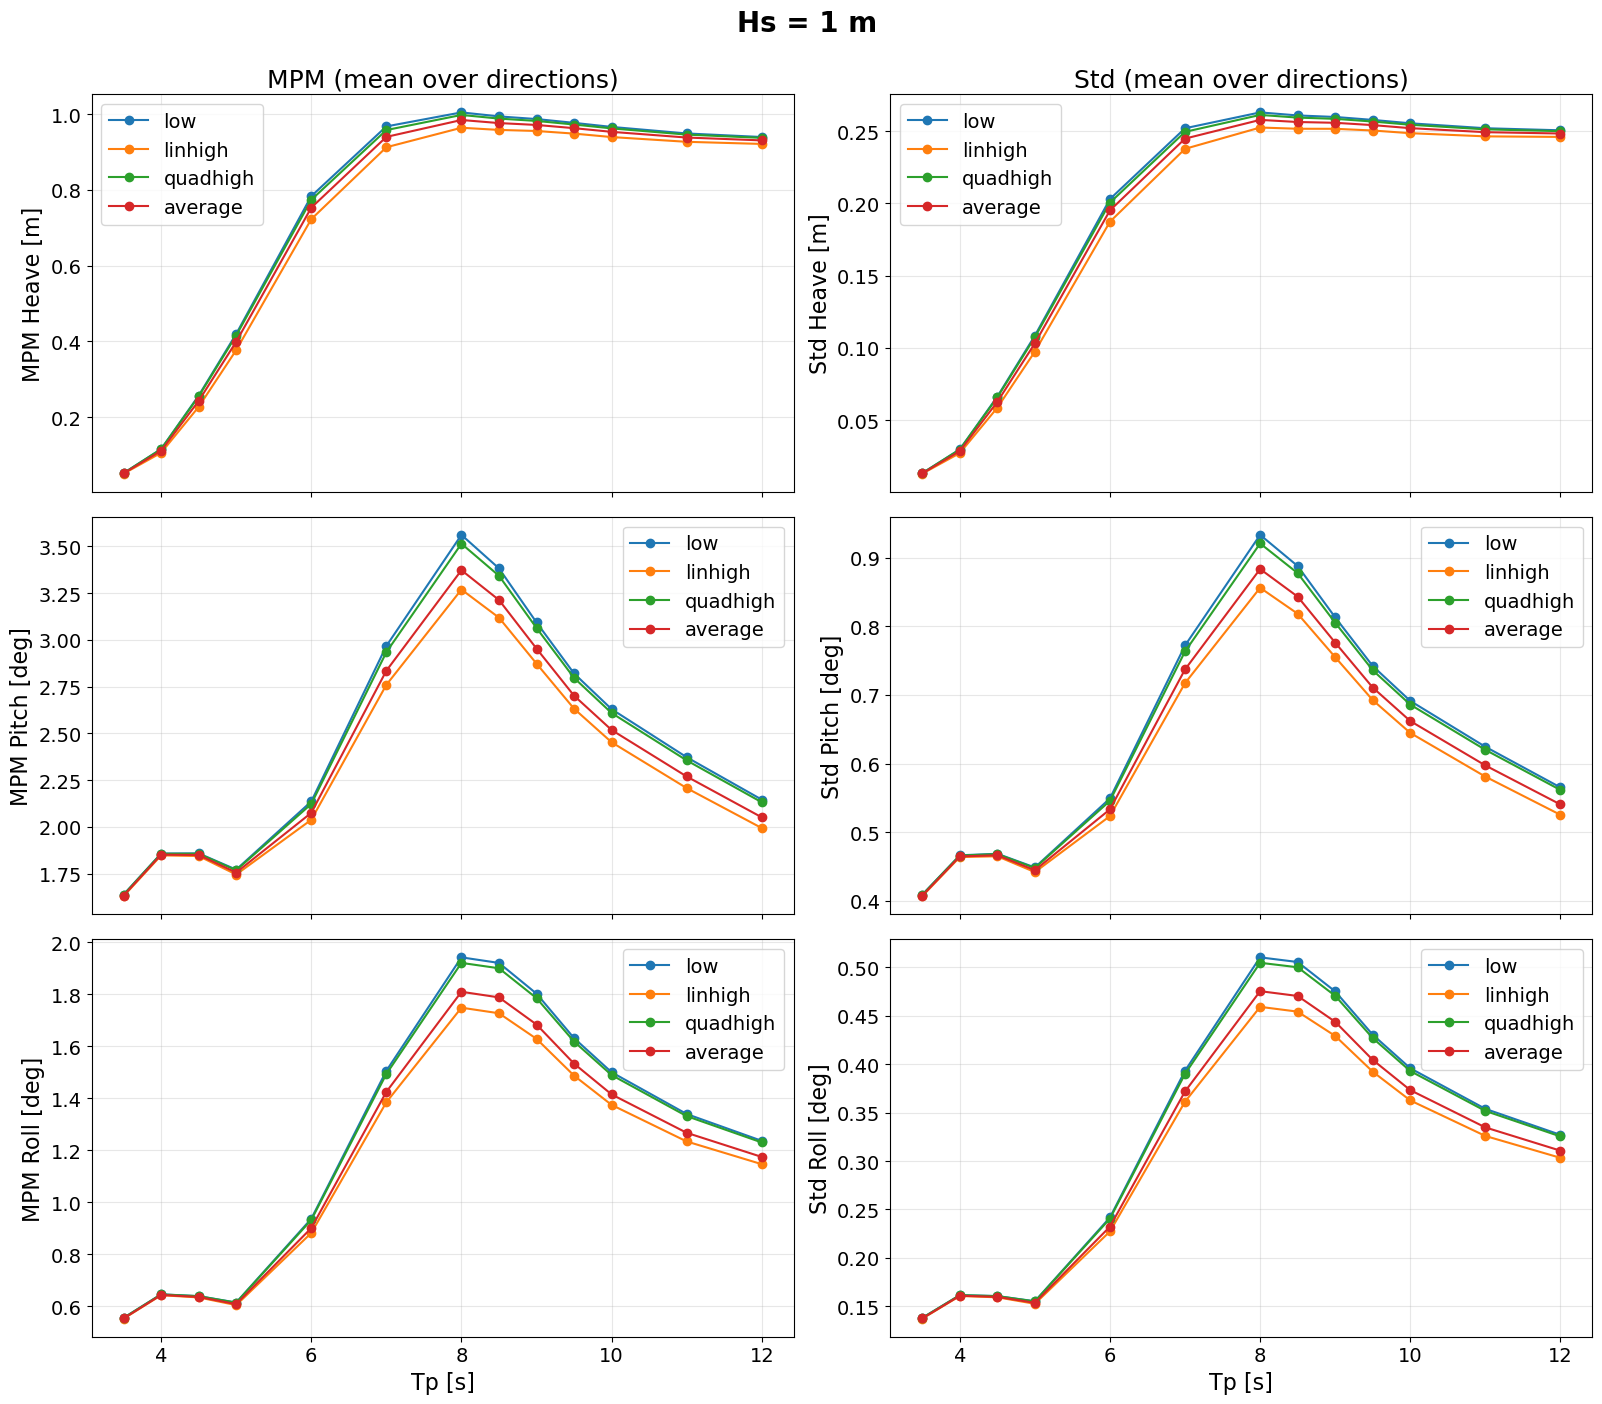

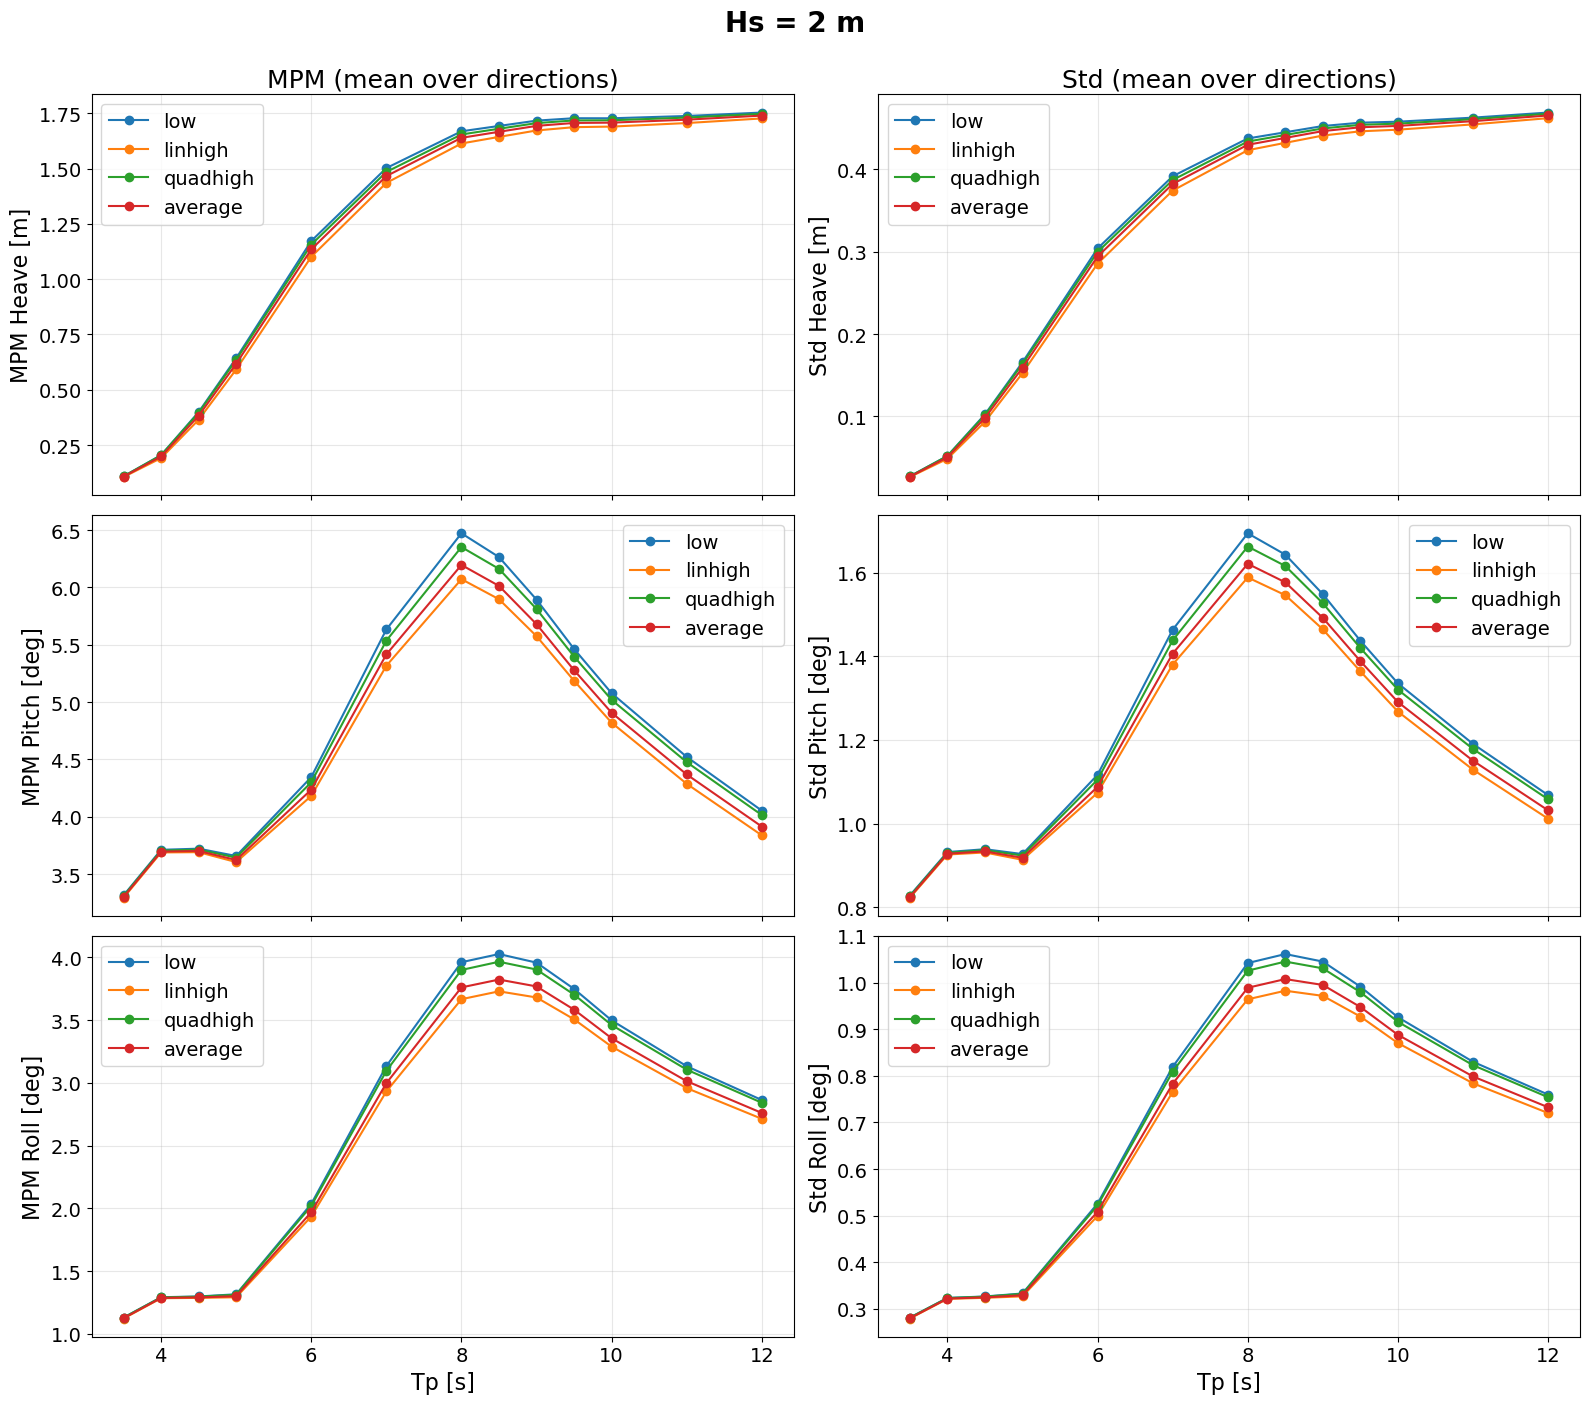

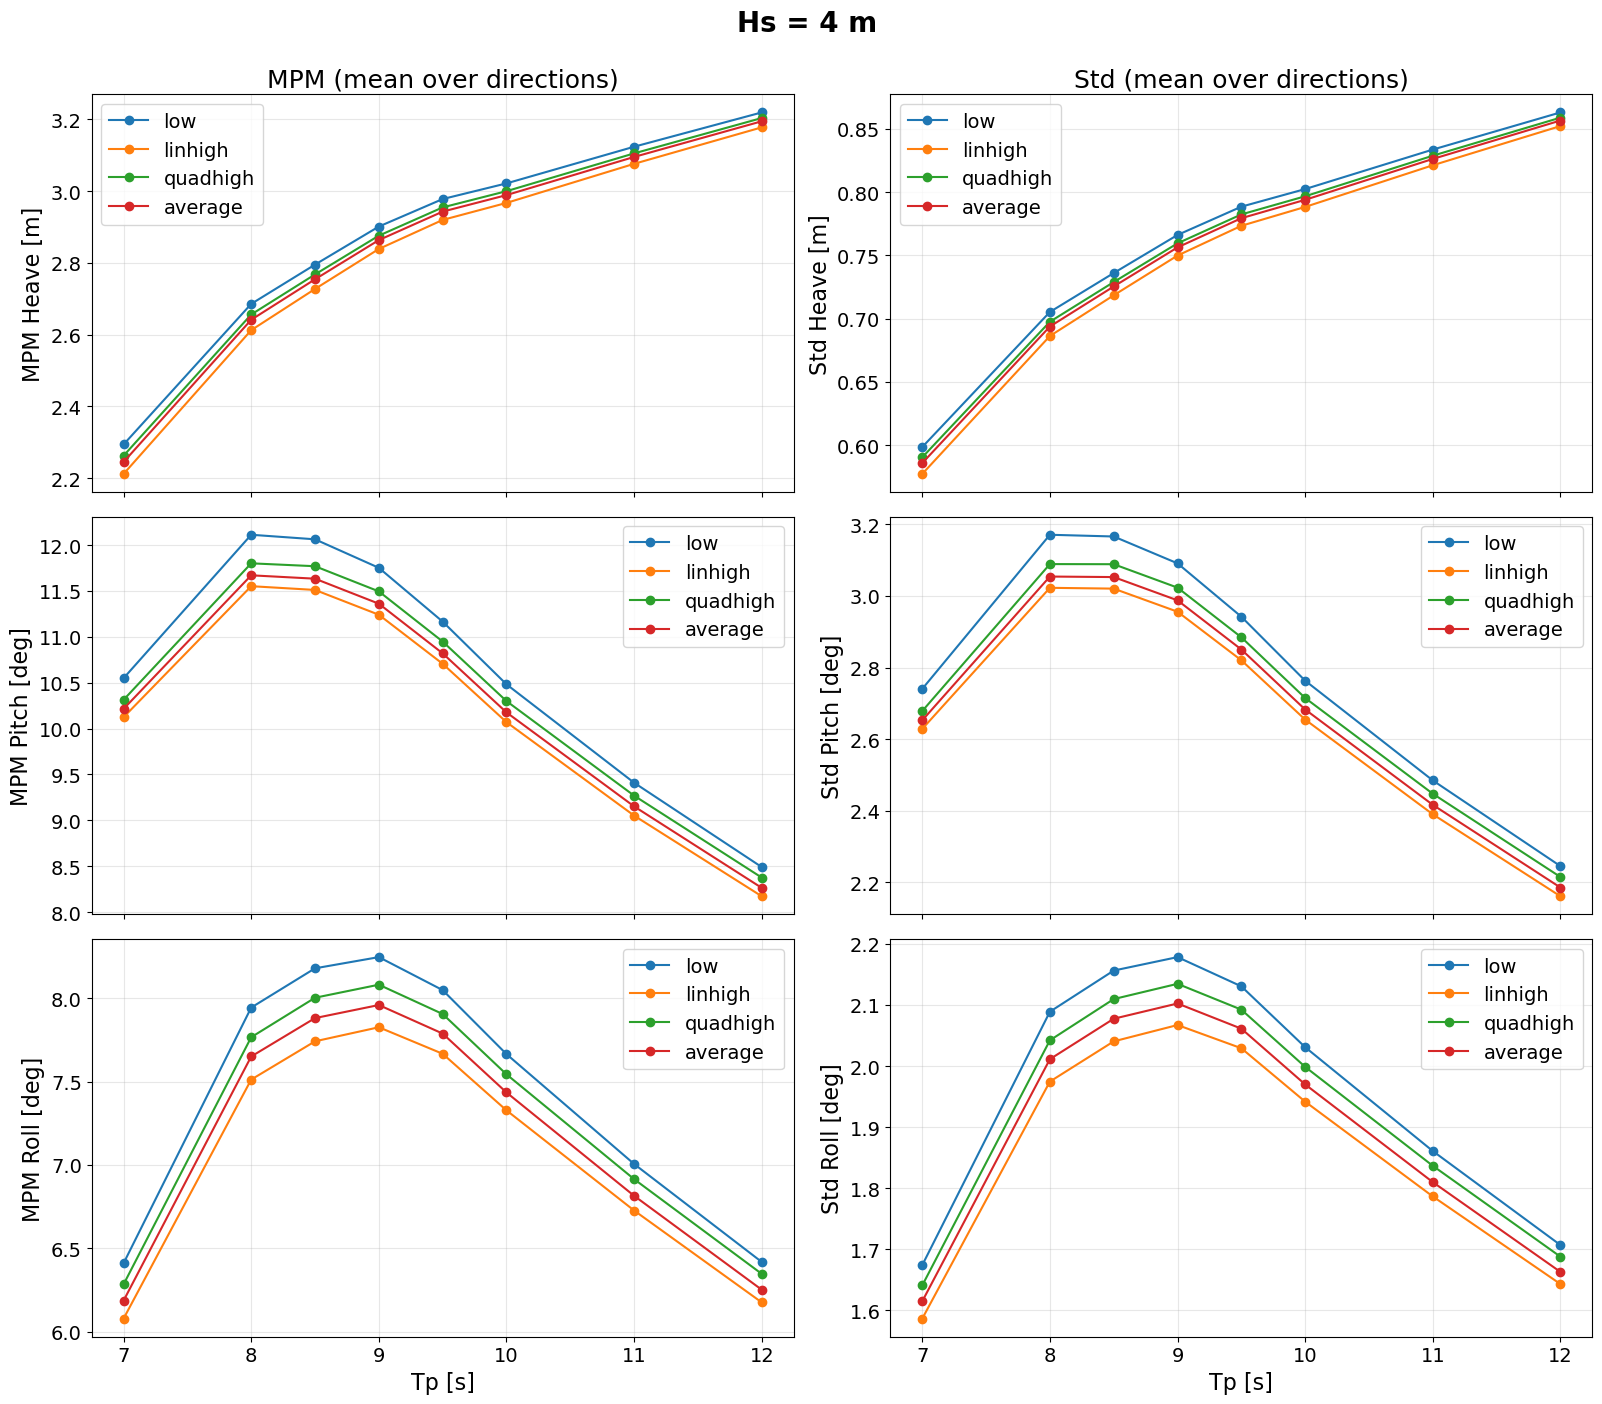

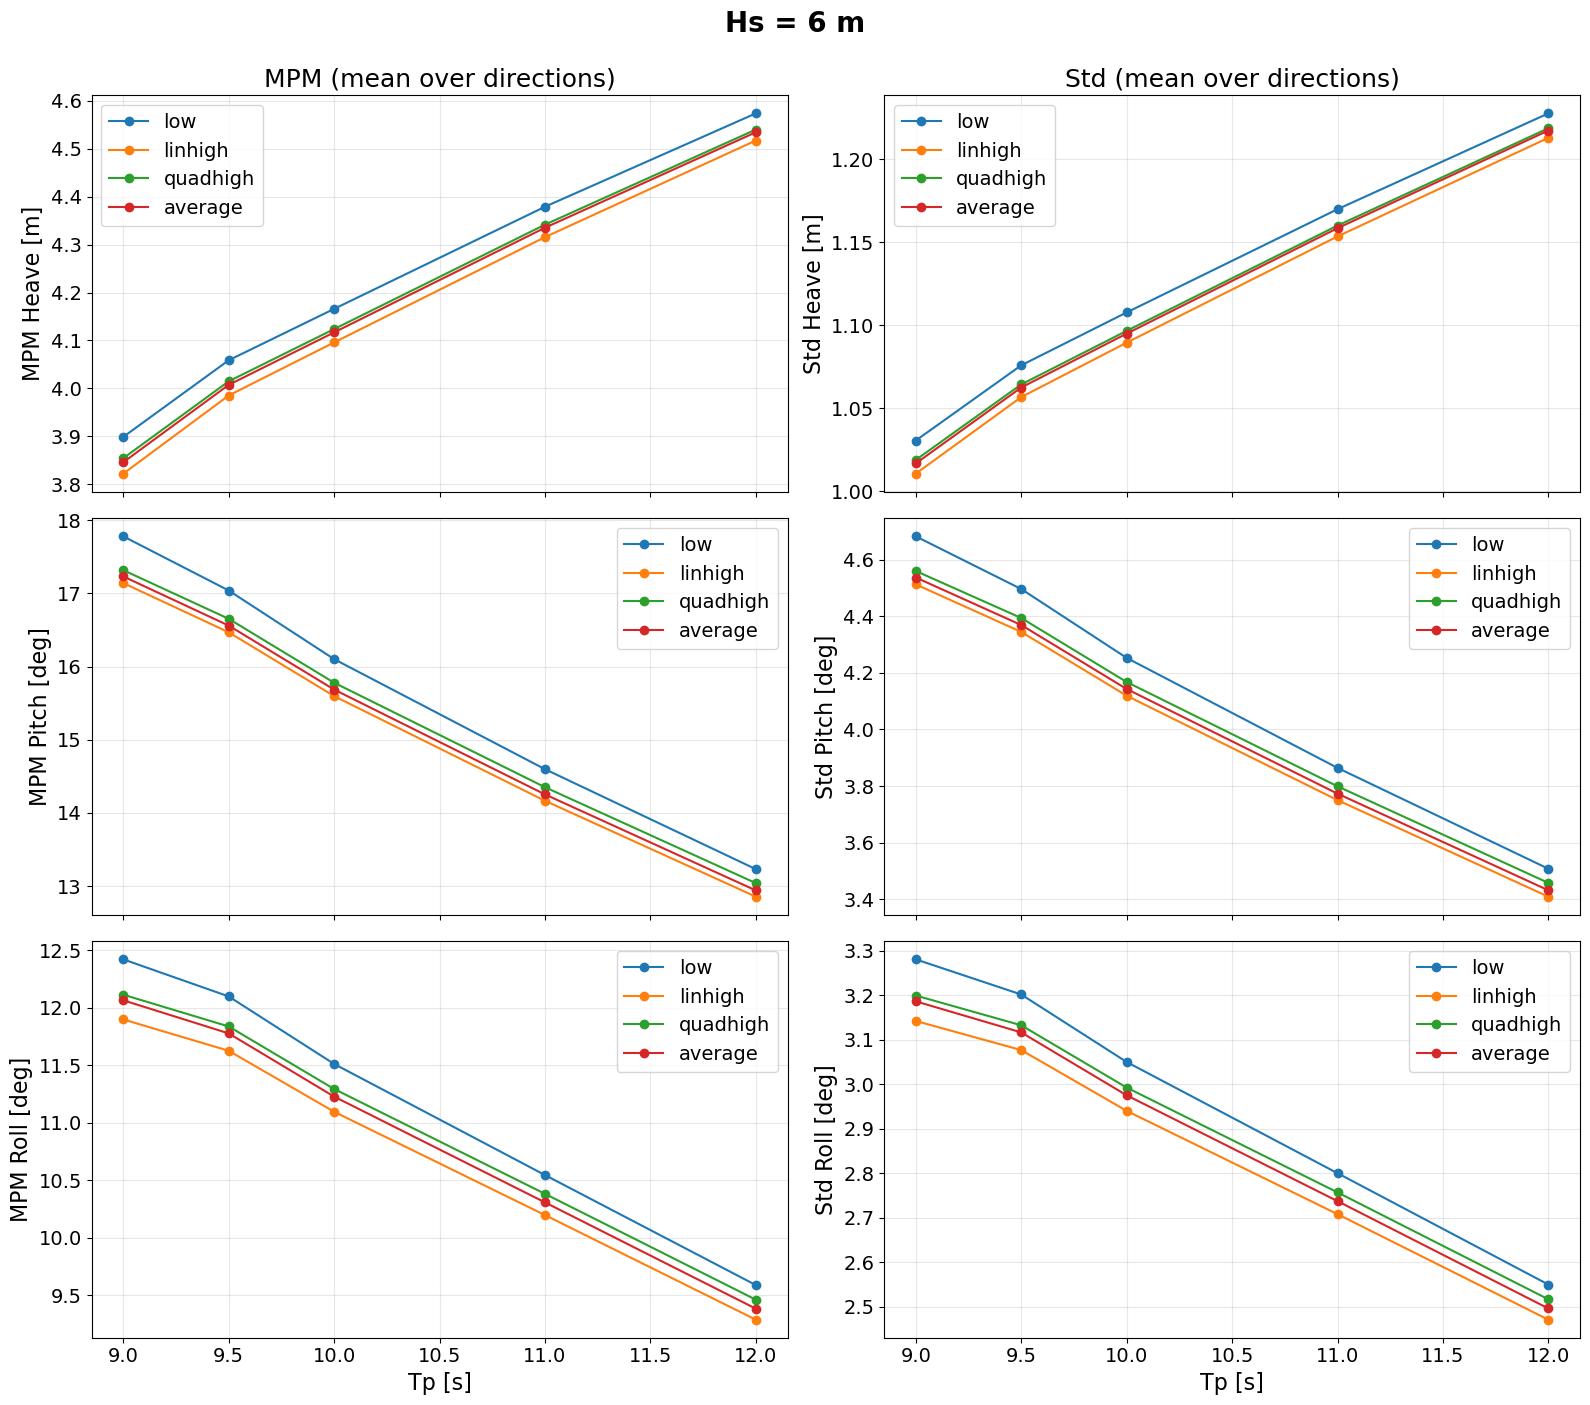

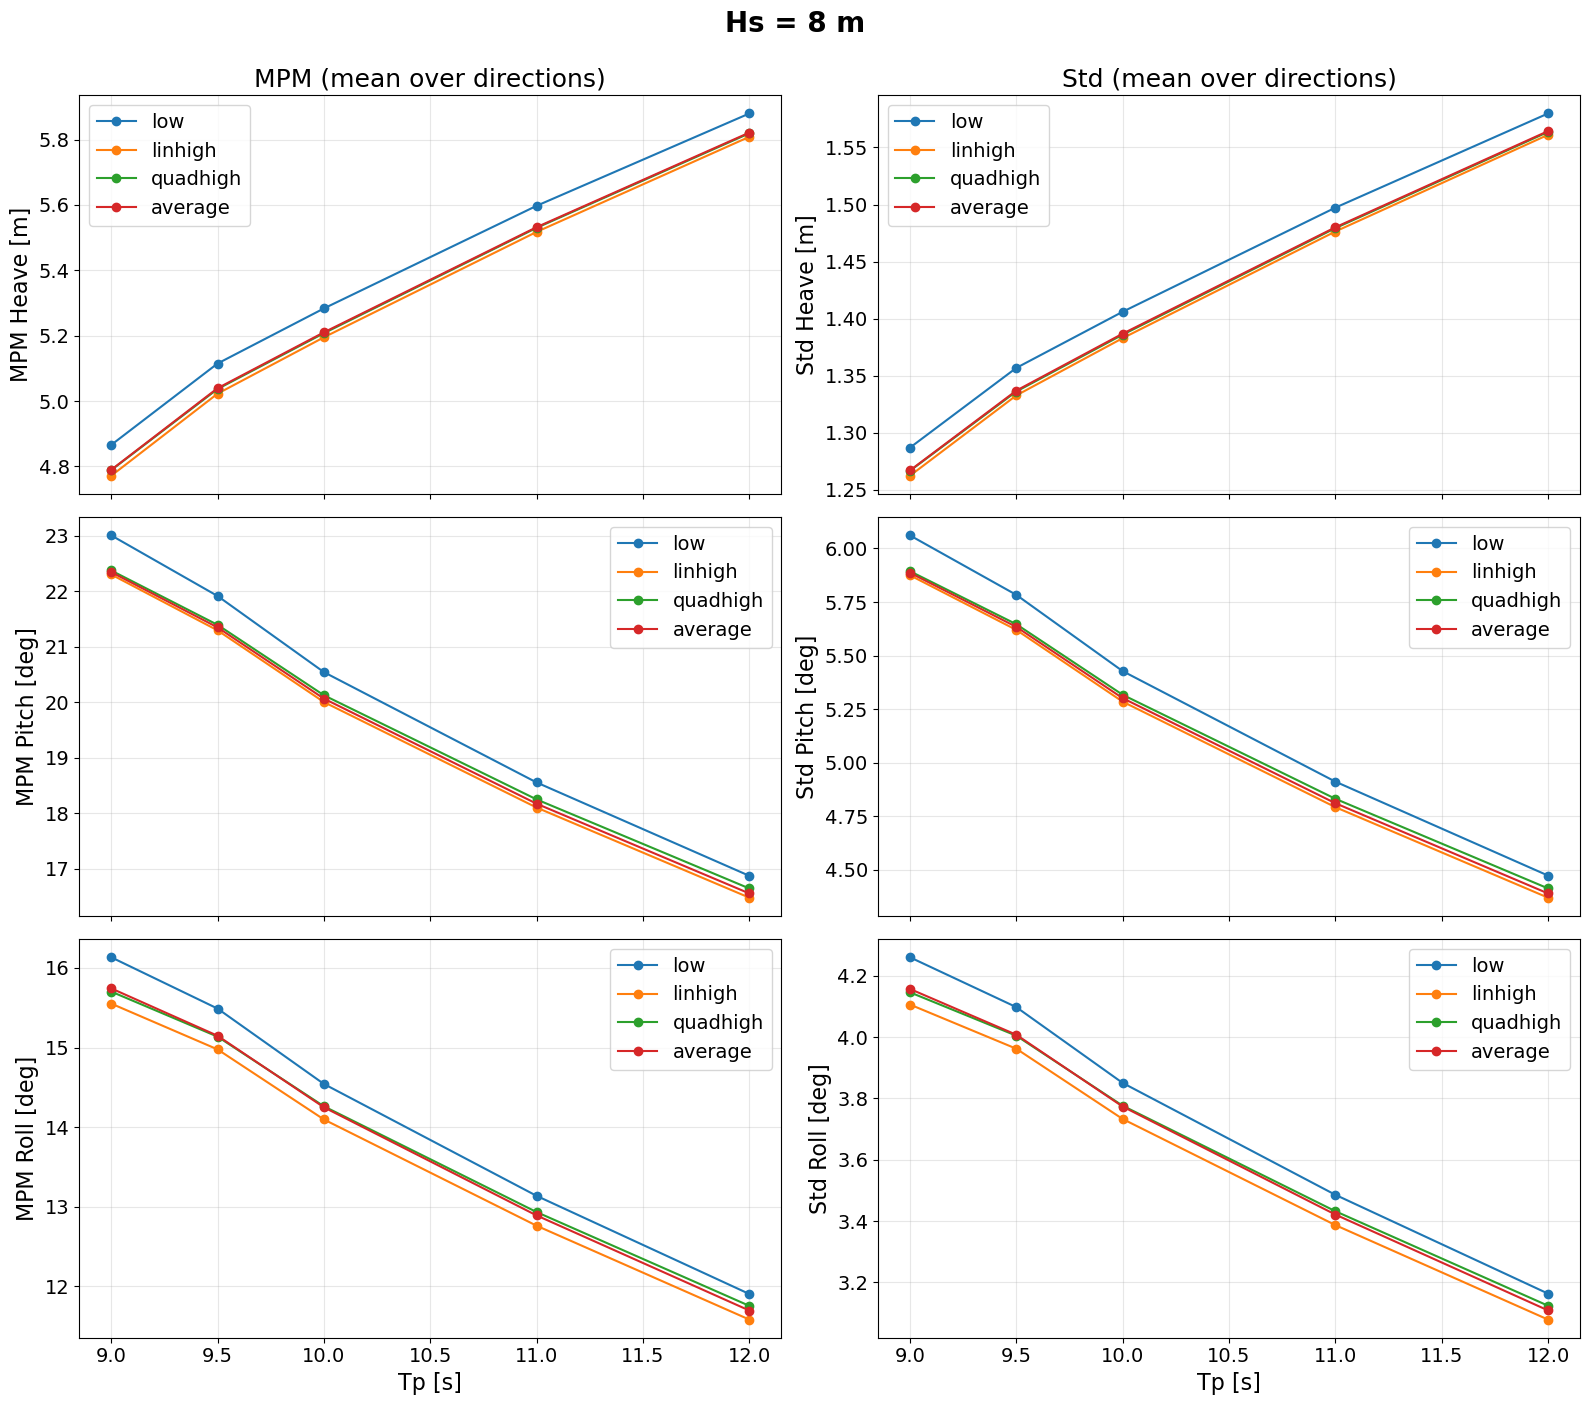

In [13]:
def plot_mpm_std_per_hs(df, hs):
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
    sub_hs = df[df['Hs'] == hs]

    for r, dof in enumerate(DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        dcol = damping_col(dof['key'])
        mpm_col = f'MPM {dof["key"]} corr'
        std_col = f'Std {dof["key"]}'

        for case in DAMPING_CASES:
            sub_case = sub_dof[sub_dof[dcol] == case]
            if sub_case.empty:
                continue
            grouped = sub_case.groupby('Tp')[[mpm_col, std_col]].mean().sort_index()
            color = DAMPING_COLORS[case]

            axes[r, 0].plot(grouped.index, grouped[mpm_col], 'o-', label=case, color=color)
            axes[r, 1].plot(grouped.index, grouped[std_col], 'o-', label=case, color=color)

        axes[r, 0].set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]')
        axes[r, 1].set_ylabel(f'Std {dof["name"]} [{dof["unit"]}]')
        axes[r, 0].grid(True, alpha=0.3)
        axes[r, 1].grid(True, alpha=0.3)
        axes[r, 0].legend()
        axes[r, 1].legend()

    axes[2, 0].set_xlabel('Tp [s]')
    axes[2, 1].set_xlabel('Tp [s]')
    axes[0, 0].set_title('MPM (mean over directions)')
    axes[0, 1].set_title('Std (mean over directions)')
    fig.suptitle(f'Hs = {hs} m', y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    return fig

for hs in HS_VALUES:
    plot_mpm_std_per_hs(df, hs)
plt.show()

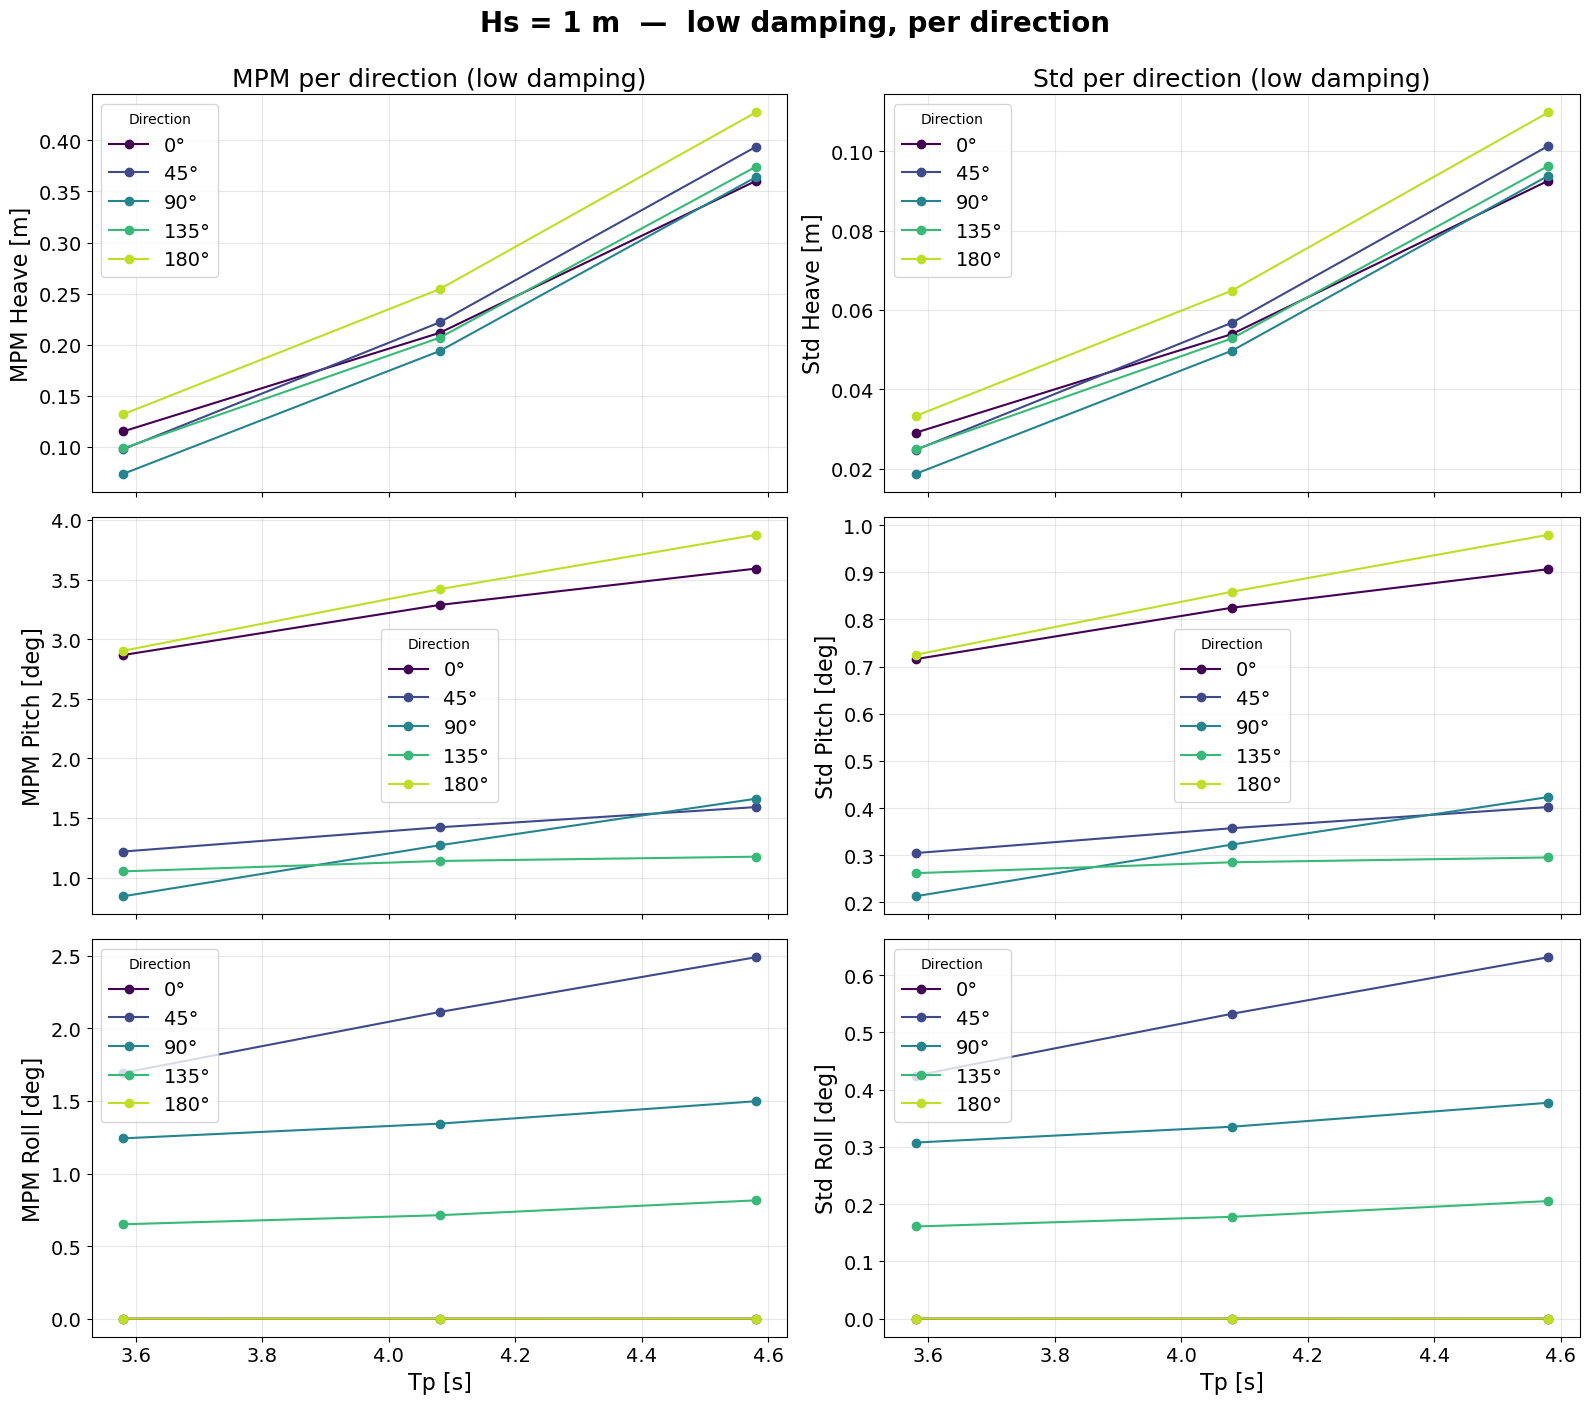

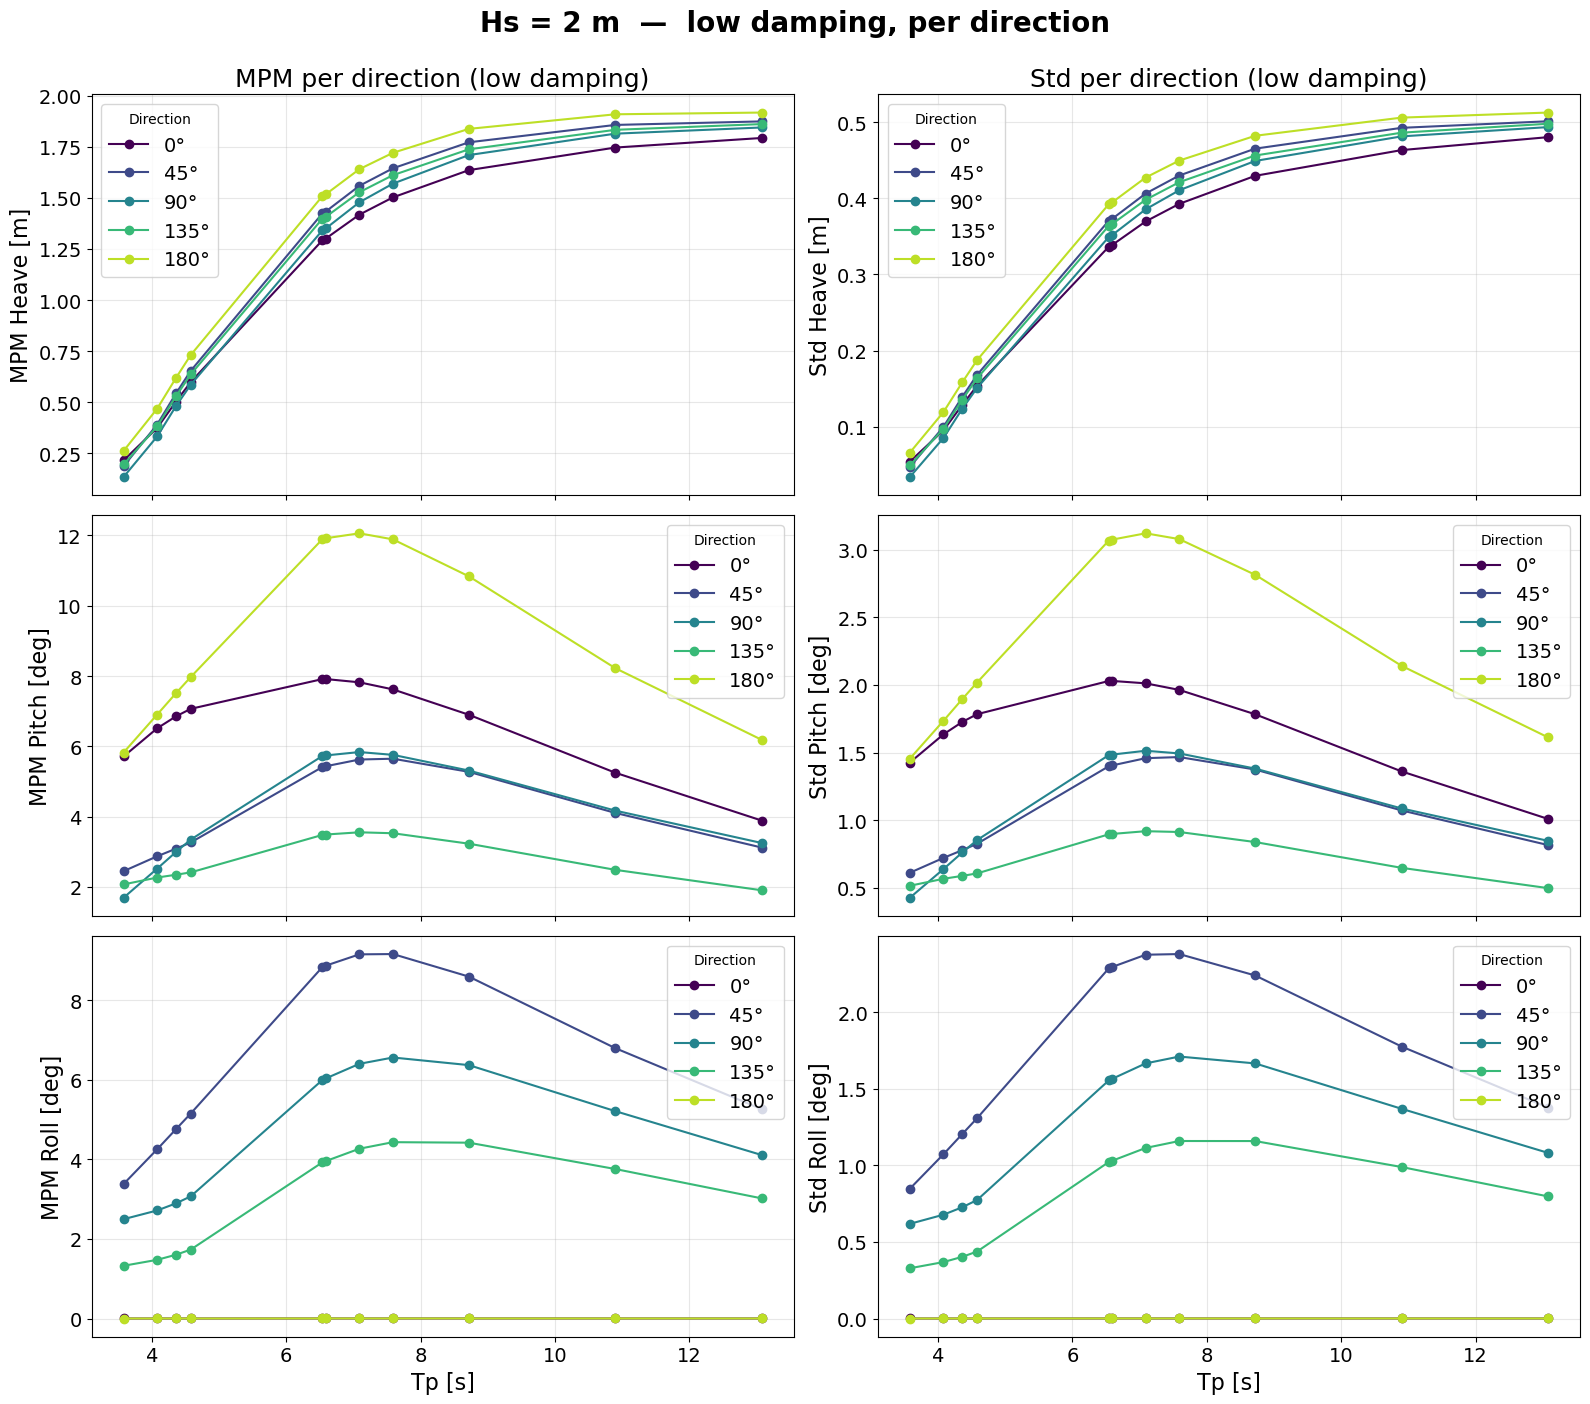

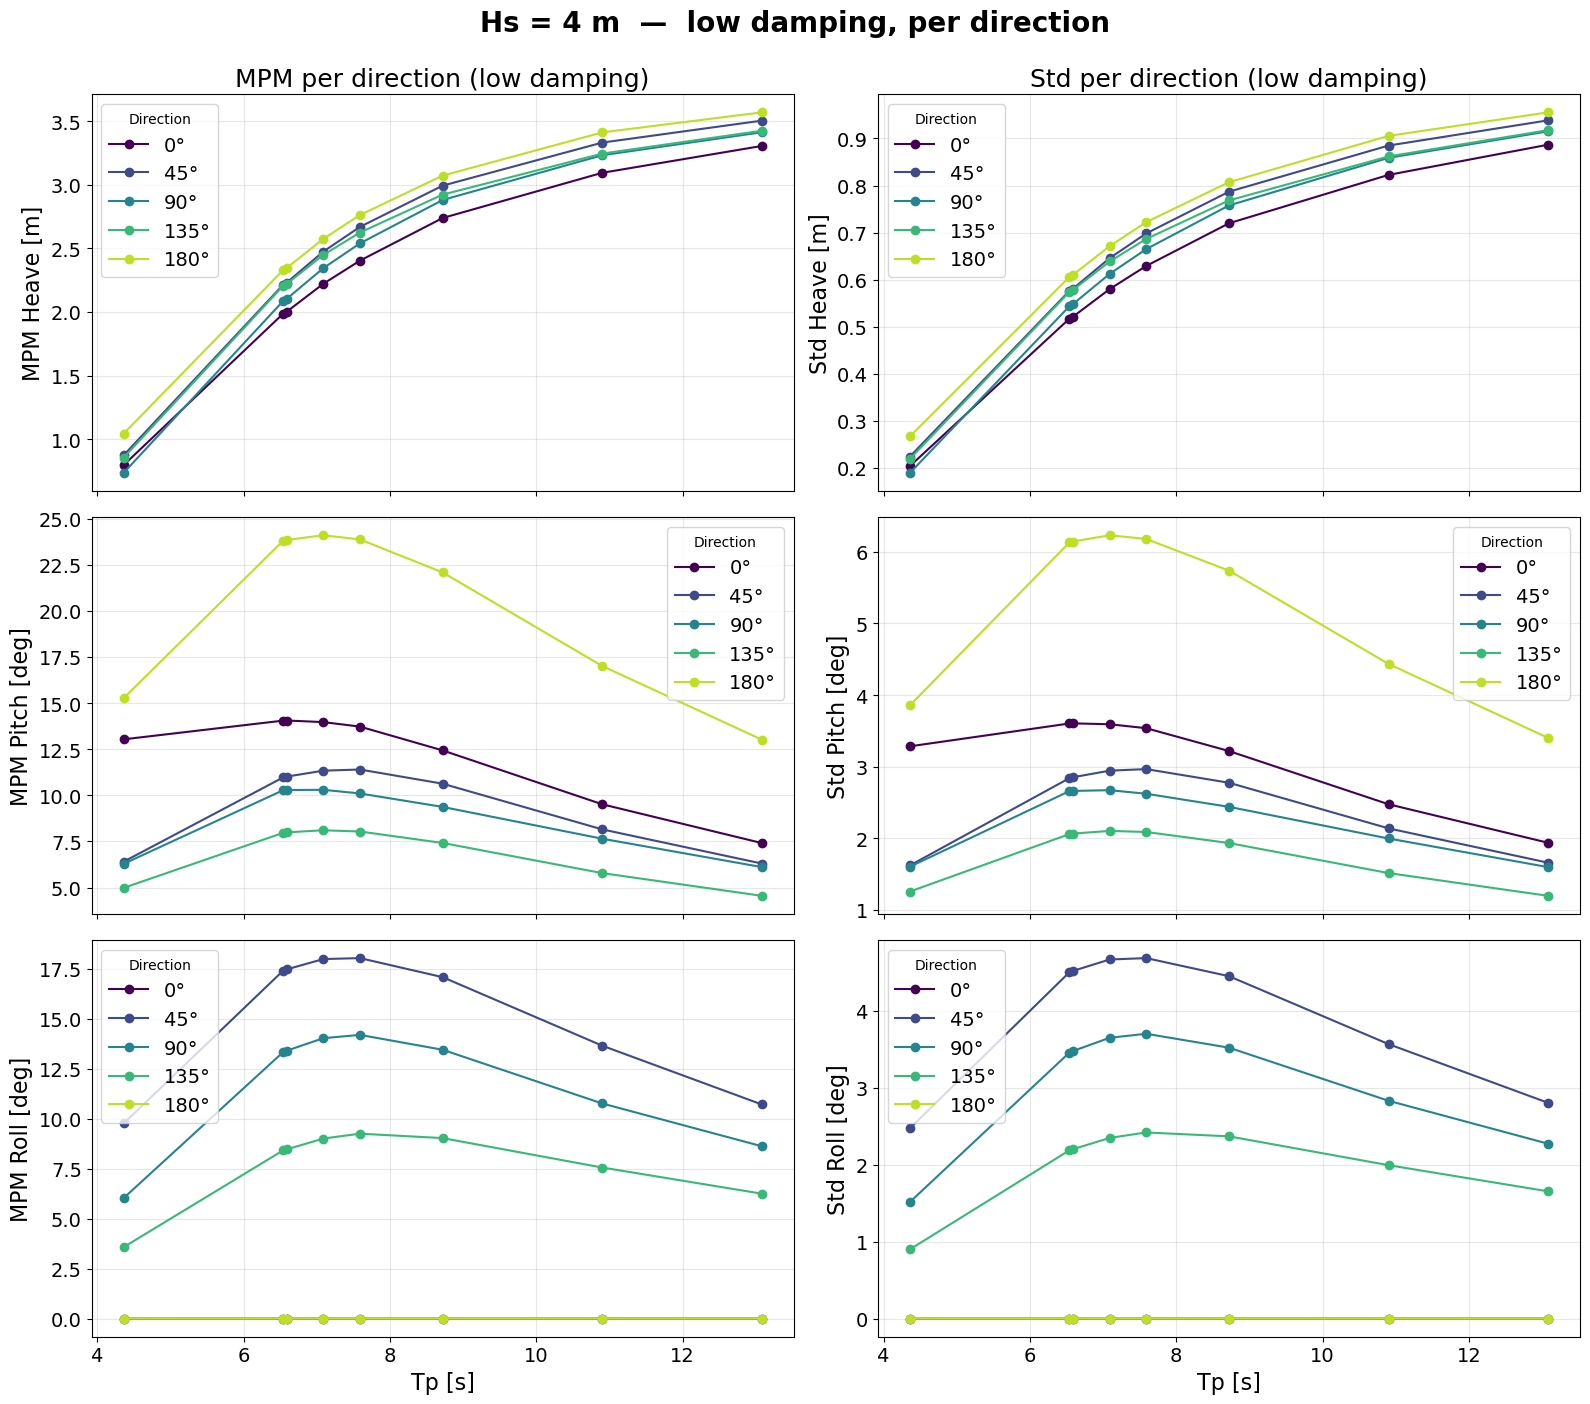

In [ ]:
# 3x2 subplots per Hs — low damping only, one line per direction

DIRECTIONS = sorted(df['Direction'].unique())
DIR_COLORS = plt.cm.viridis(np.linspace(0, 0.9, len(DIRECTIONS)))

for hs in HS_VALUES:
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
    sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]

    for r, dof in enumerate(DOFS):
        mpm_col = f'MPM {dof["key"]} corr'
        std_col = f'std {dof["key"]}'

        for d, direction in enumerate(DIRECTIONS):
            sub_dir = sub_hs[sub_hs['Direction'] == direction].sort_values('Tp')
            if sub_dir.empty:
                continue
            axes[r, 0].plot(sub_dir['Tp'], sub_dir[mpm_col], 'o-',
                            label=f'{direction}°', color=DIR_COLORS[d])
            axes[r, 1].plot(sub_dir['Tp'], sub_dir[std_col], 'o-',
                            label=f'{direction}°', color=DIR_COLORS[d])

        axes[r, 0].set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]')
        axes[r, 1].set_ylabel(f'Std {dof["name"]} [{dof["unit"]}]')
        axes[r, 0].grid(True, alpha=0.3)
        axes[r, 1].grid(True, alpha=0.3)
        axes[r, 0].legend(title='Direction')
        axes[r, 1].legend(title='Direction')

    axes[2, 0].set_xlabel('Tp [s]')
    axes[2, 1].set_xlabel('Tp [s]')
    axes[0, 0].set_title('MPM per direction (low damping)')
    axes[0, 1].set_title('Std per direction (low damping)')
    fig.suptitle(f'Hs = {hs} m  —  low damping, per direction',
                 y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()

plt.show()

## 3. Percentage difference vs the `low` case (6 subplots per Hs)

Computed as `(case - low) / low * 100` per Tp, after averaging over directions.  
The `low` case itself is the baseline and is not drawn, so each subplot has 3 lines.

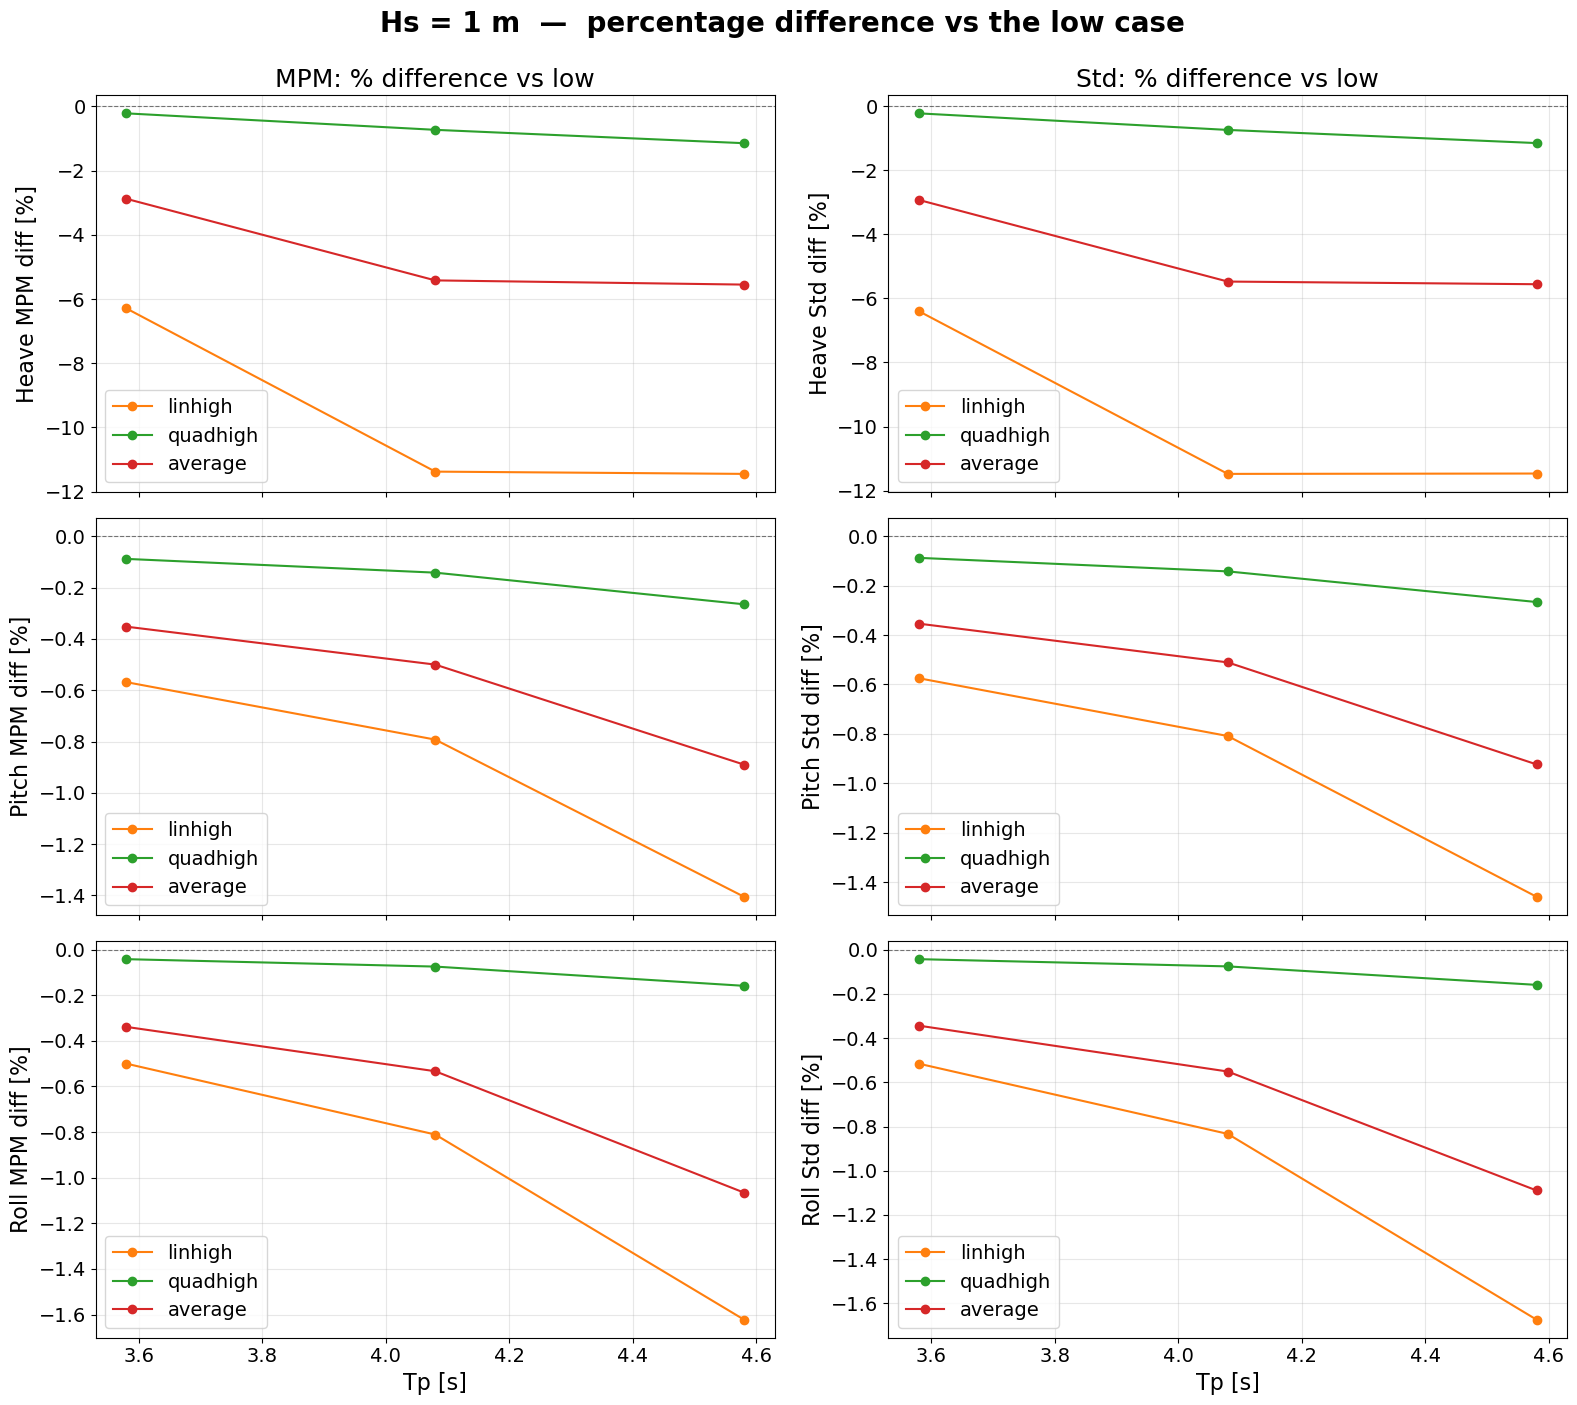

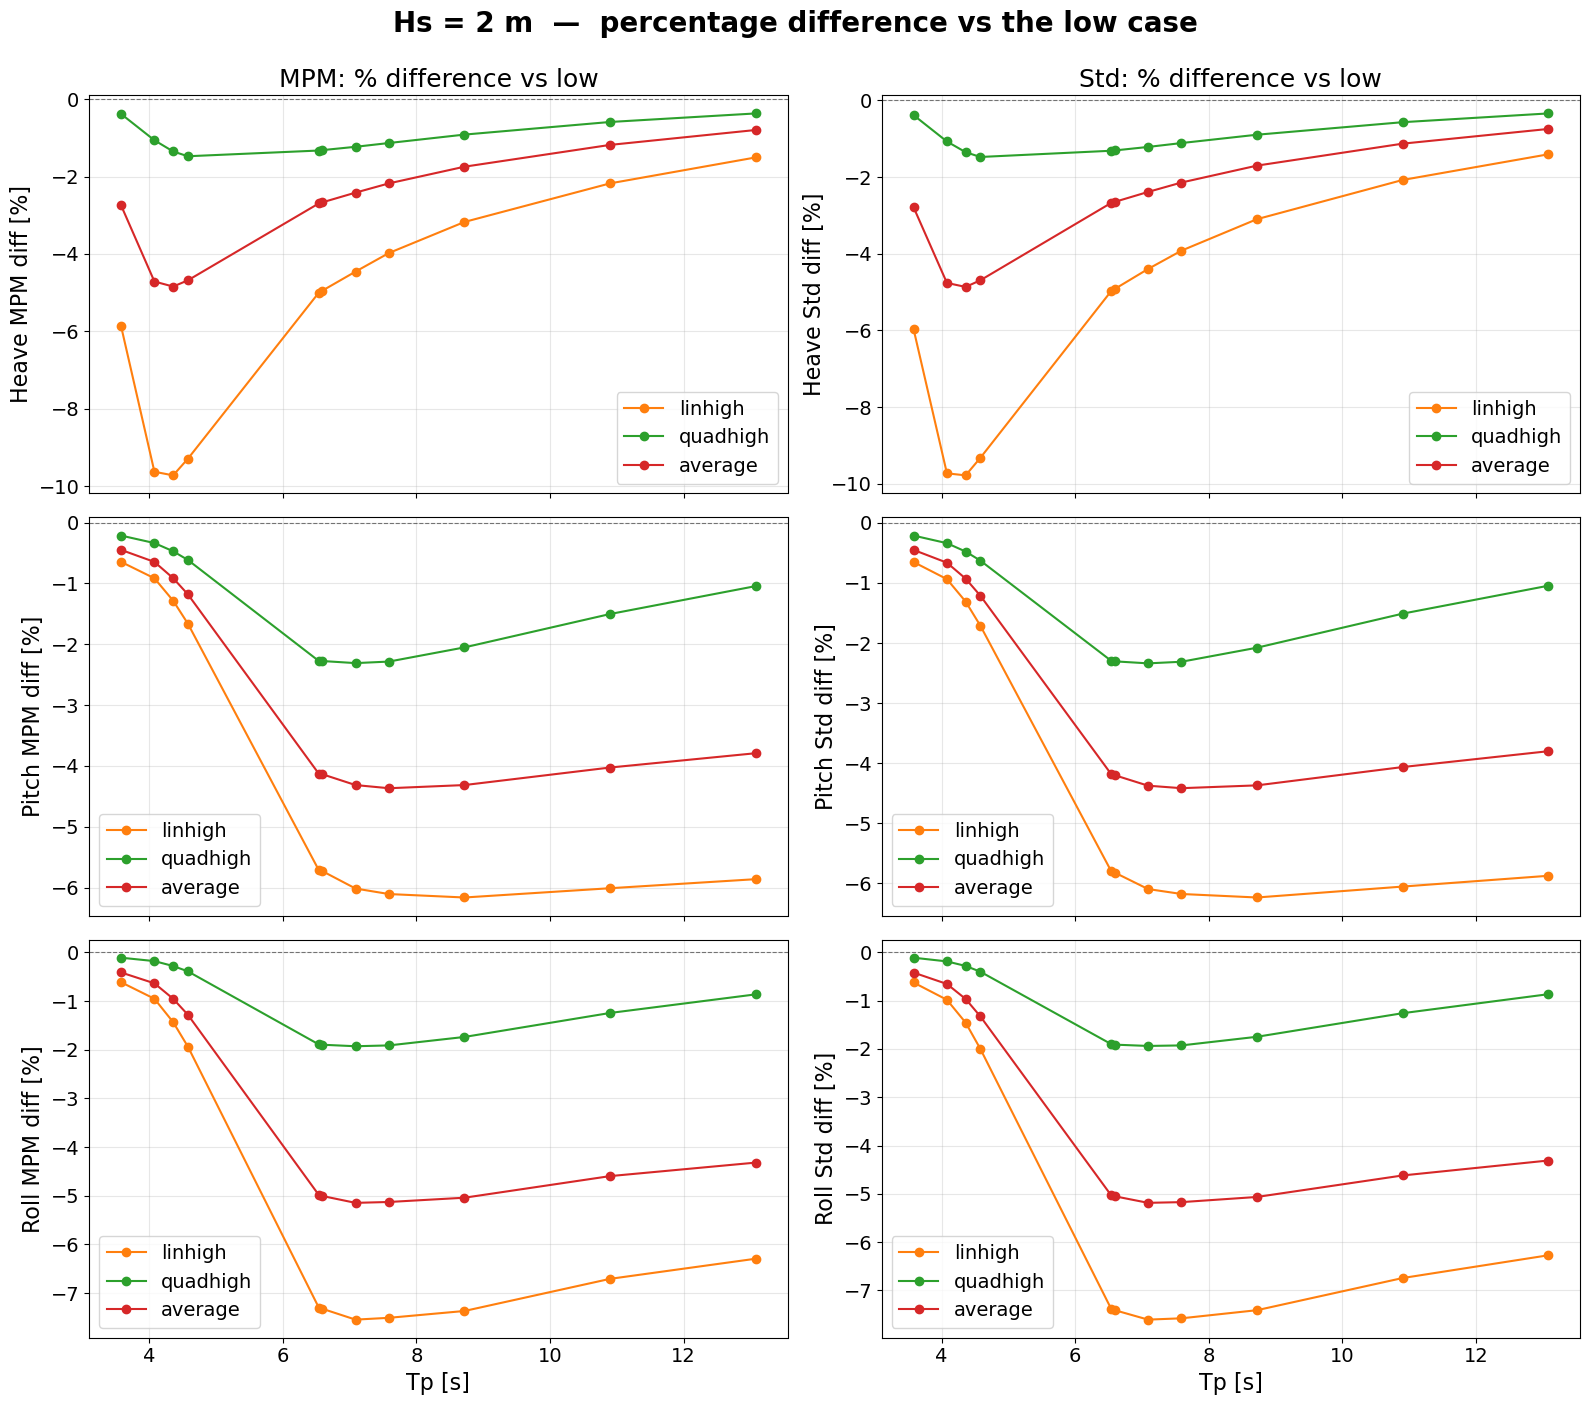

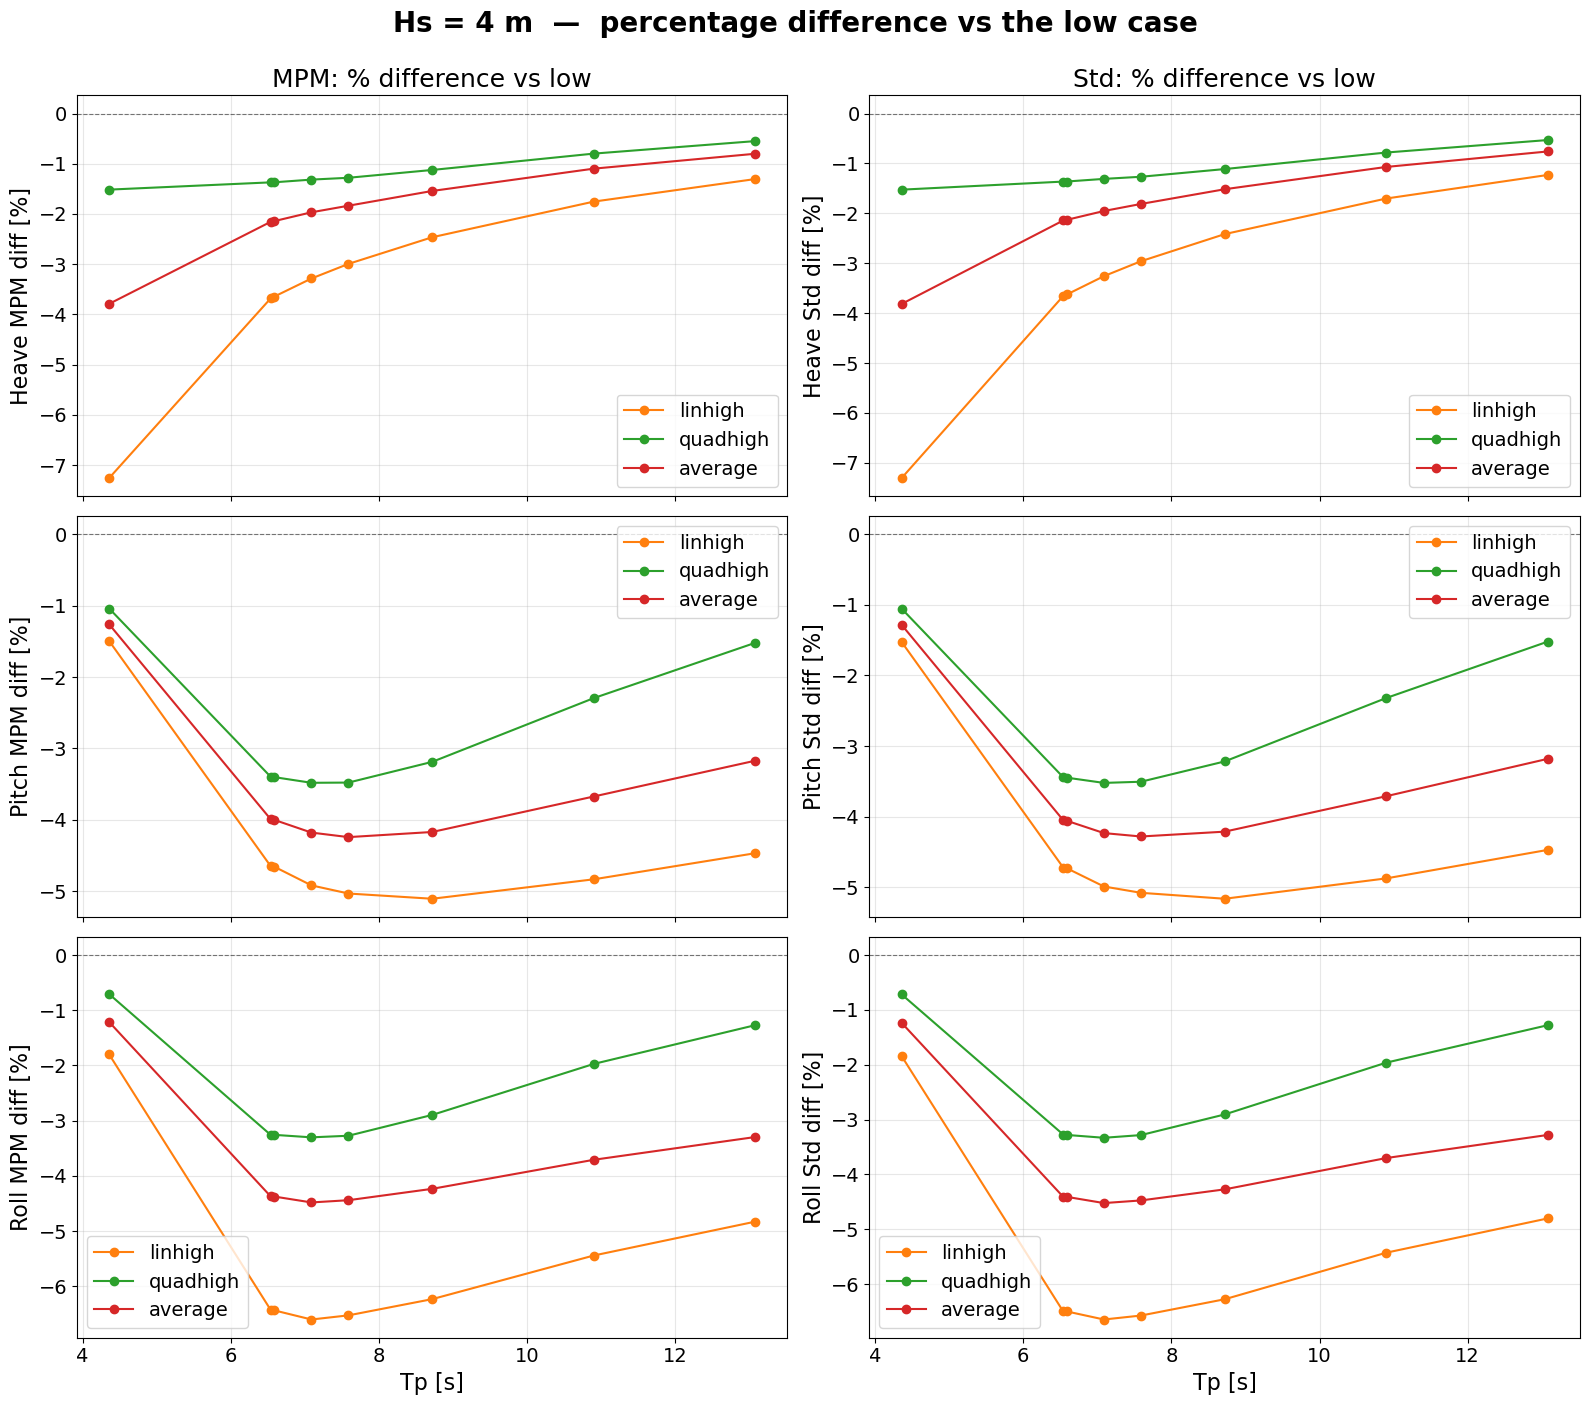

In [ ]:
def plot_pct_diff_per_hs(df, hs):
    fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
    sub_hs = df[df['Hs'] == hs]

    for r, dof in enumerate(DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        dcol = damping_col(dof['key'])
        mpm_col = f'MPM {dof["key"]} corr'
        std_col = f'std {dof["key"]}'

        # baseline: low
        base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[[mpm_col, std_col]].mean().sort_index()

        for case in ['linhigh', 'quadhigh', 'average']:
            sub_case = sub_dof[sub_dof[dcol] == case]
            if sub_case.empty:
                continue
            grouped = sub_case.groupby('Tp')[[mpm_col, std_col]].mean().sort_index()
            common_tp = grouped.index.intersection(base.index)
            if len(common_tp) == 0:
                continue
            pct_mpm = (grouped.loc[common_tp, mpm_col] - base.loc[common_tp, mpm_col]) / base.loc[common_tp, mpm_col] * 100
            pct_std = (grouped.loc[common_tp, std_col] - base.loc[common_tp, std_col]) / base.loc[common_tp, std_col] * 100
            color = DAMPING_COLORS[case]

            axes[r, 0].plot(common_tp, pct_mpm, 'o-', label=case, color=color)
            axes[r, 1].plot(common_tp, pct_std, 'o-', label=case, color=color)

        axes[r, 0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        axes[r, 1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        axes[r, 0].set_ylabel(f'{dof["name"]} MPM diff [%]')
        axes[r, 1].set_ylabel(f'{dof["name"]} Std diff [%]')
        axes[r, 0].grid(True, alpha=0.3)
        axes[r, 1].grid(True, alpha=0.3)
        axes[r, 0].legend()
        axes[r, 1].legend()

    axes[2, 0].set_xlabel('Tp [s]')
    axes[2, 1].set_xlabel('Tp [s]')
    axes[0, 0].set_title('MPM: % difference vs low')
    axes[0, 1].set_title('Std: % difference vs low')
    fig.suptitle(f'Hs = {hs} m  —  percentage difference vs the low case', y=1.00,
                 fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    return fig

for hs in HS_VALUES:
    plot_pct_diff_per_hs(df, hs)
plt.show()

## 4. Most extreme MPM per DOF (max over directions) for all damping cases

For every (Hs, Tp, damping case), take the **max** of `|MPM − mean|` across the remaining directions.  
One subplot per DOF, one line per damping case. All Hs are pooled here — different markers for different Hs.

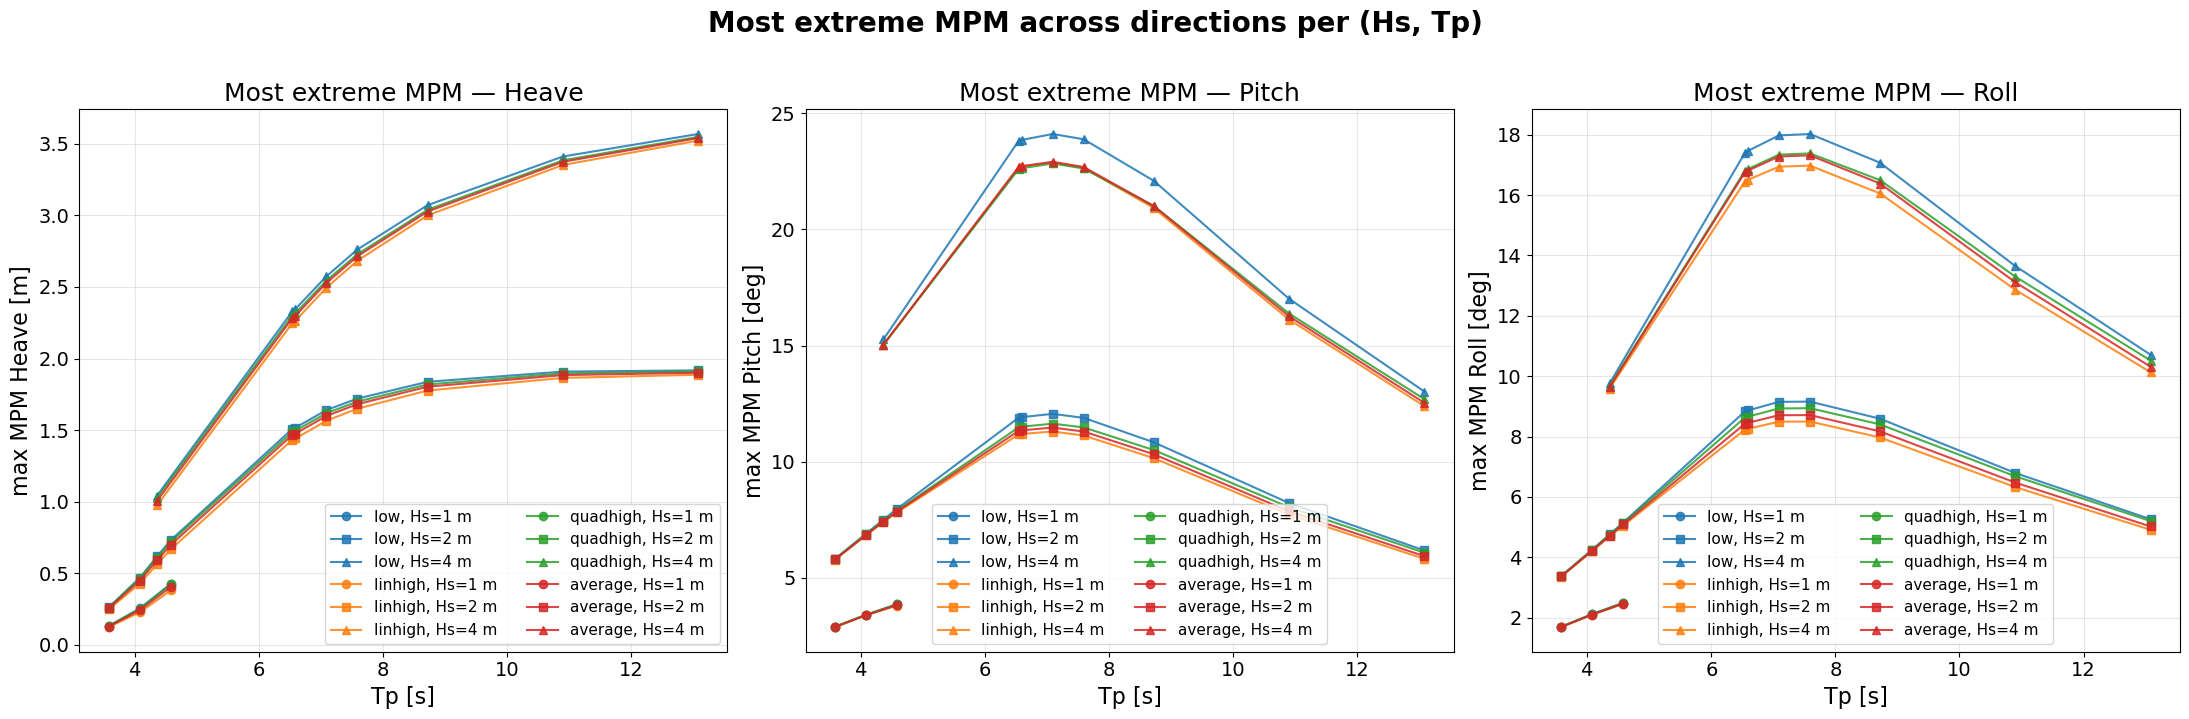

In [ ]:
HS_MARKERS = {1: 'o', 2: 's', 4: '^'}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_col = f'MPM {dof["key"]} corr'

    for case in DAMPING_CASES:
        sub_case = sub_dof[sub_dof[dcol] == case]
        if sub_case.empty:
            continue
        # Max over directions per (Hs, Tp)
        extremes = sub_case.groupby(['Hs', 'Tp'])[mpm_col].max().reset_index()
        color = DAMPING_COLORS[case]

        for hs in HS_VALUES:
            sub_hs = extremes[extremes['Hs'] == hs].sort_values('Tp')
            if sub_hs.empty:
                continue
            label = f'{case}, Hs={hs} m'
            ax.plot(sub_hs['Tp'], sub_hs[mpm_col],
                    marker=HS_MARKERS[hs], linestyle='-',
                    color=color, label=label, alpha=0.85)

    ax.set_title(f'Most extreme MPM — {dof["name"]}')
    ax.set_xlabel('Tp [s]')
    ax.set_ylabel(f'max MPM {dof["name"]} [{dof["unit"]}]')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=11)

fig.suptitle('Most extreme MPM across directions per (Hs, Tp)', y=1.02,
             fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

### Compact version — one panel per DOF, lines per damping case (averaged across Hs is misleading, so we pick the worst Hs per Tp)

Same idea but cleaner: per (Tp, damping), take the max of `|MPM − mean|` across **both** directions and Hs.  
This is the single worst-case curve per damping setting.

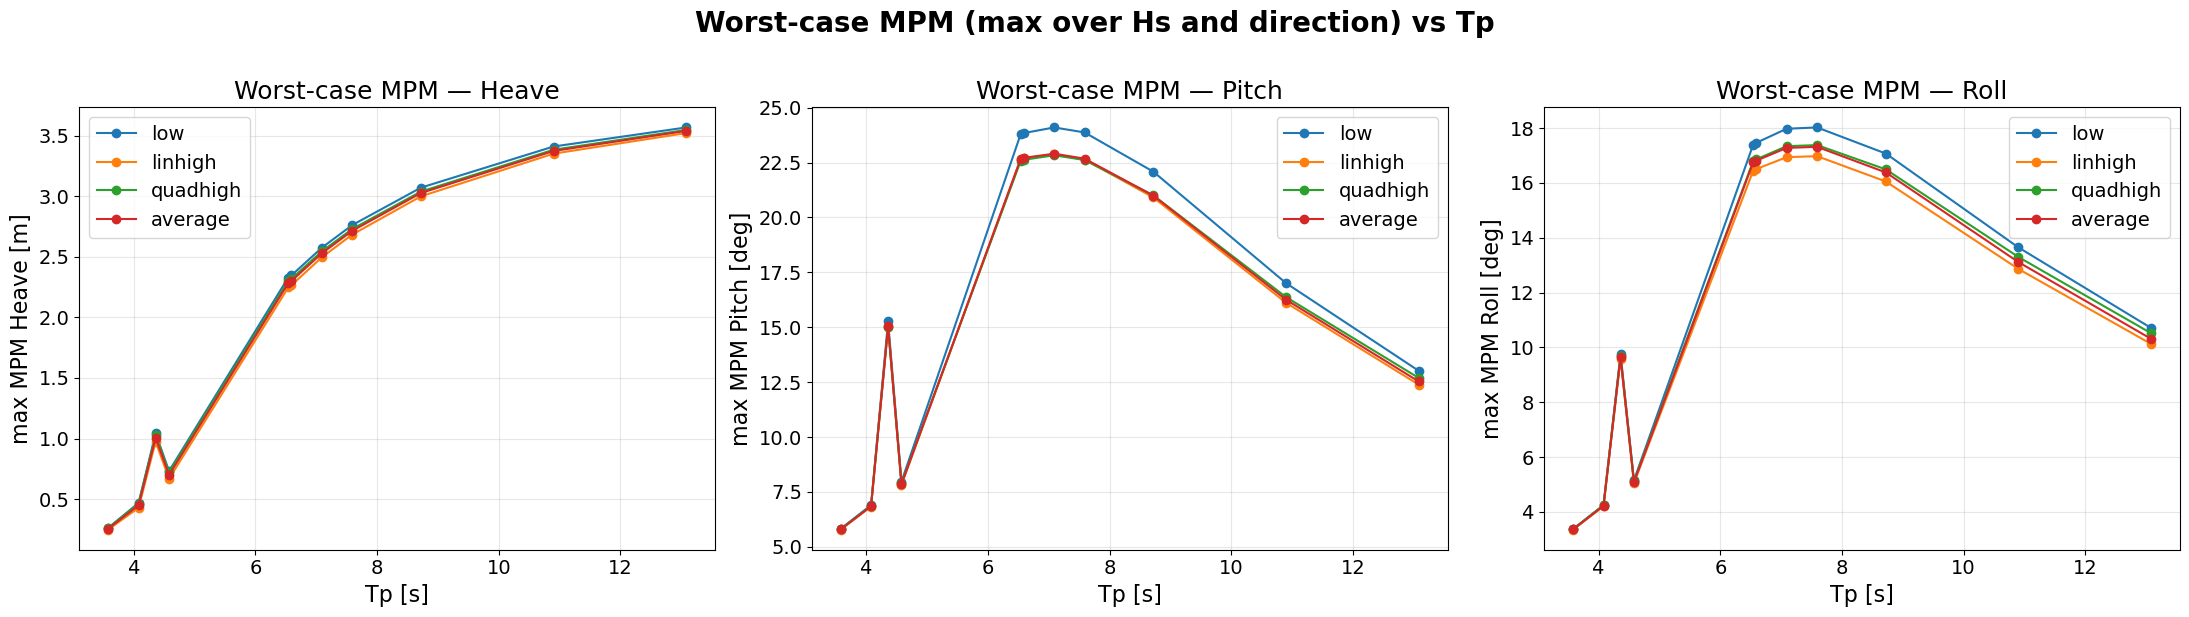

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_col = f'MPM {dof["key"]} corr'

    for case in DAMPING_CASES:
        sub_case = sub_dof[sub_dof[dcol] == case]
        if sub_case.empty:
            continue
        worst = sub_case.groupby('Tp')[mpm_col].max().sort_index()
        ax.plot(worst.index, worst.values, 'o-',
                color=DAMPING_COLORS[case], label=case)

    ax.set_title(f'Worst-case MPM — {dof["name"]}')
    ax.set_xlabel('Tp [s]')
    ax.set_ylabel(f'max MPM {dof["name"]} [{dof["unit"]}]')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Worst-case MPM (max over Hs and direction) vs Tp', y=1.02,
             fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Extra: heatmap of MPM per (Tp, Direction) for each DOF and Hs

Useful to see which (Tp, Direction) combinations drive the response, instead of hiding the directionality in an average.

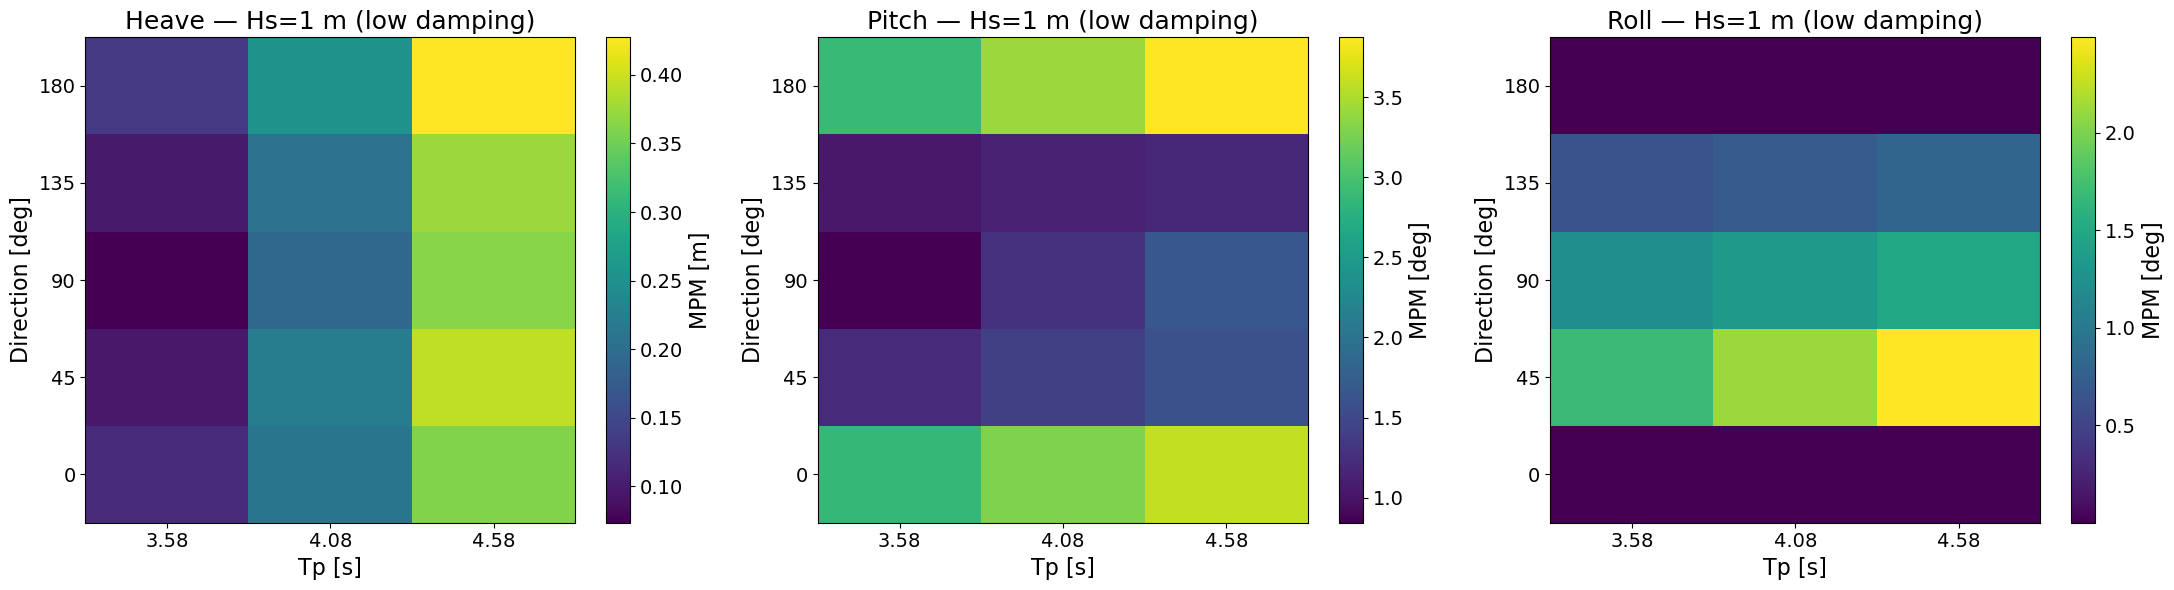

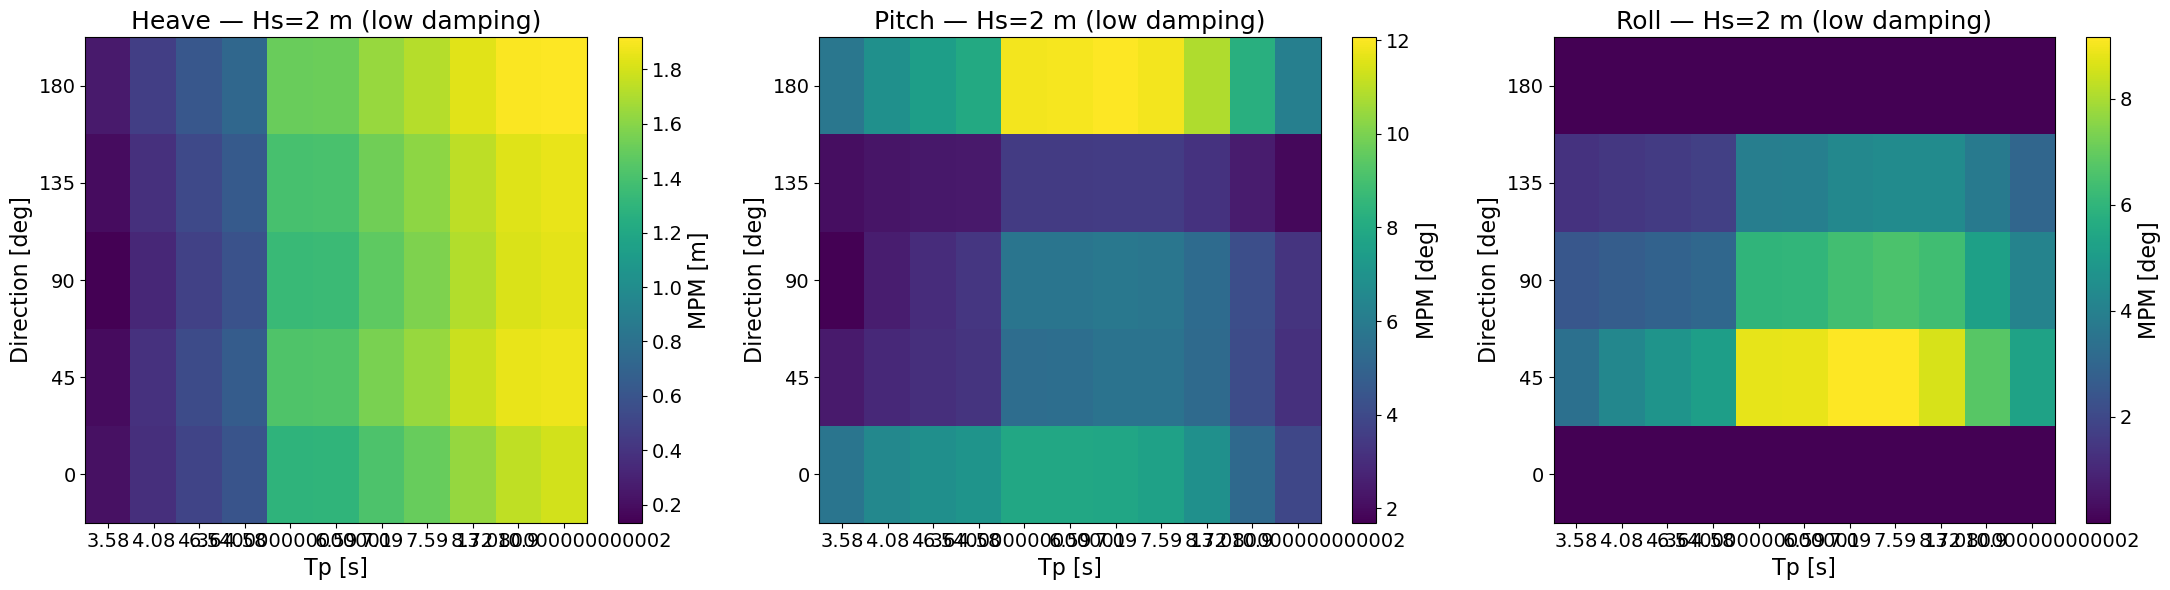

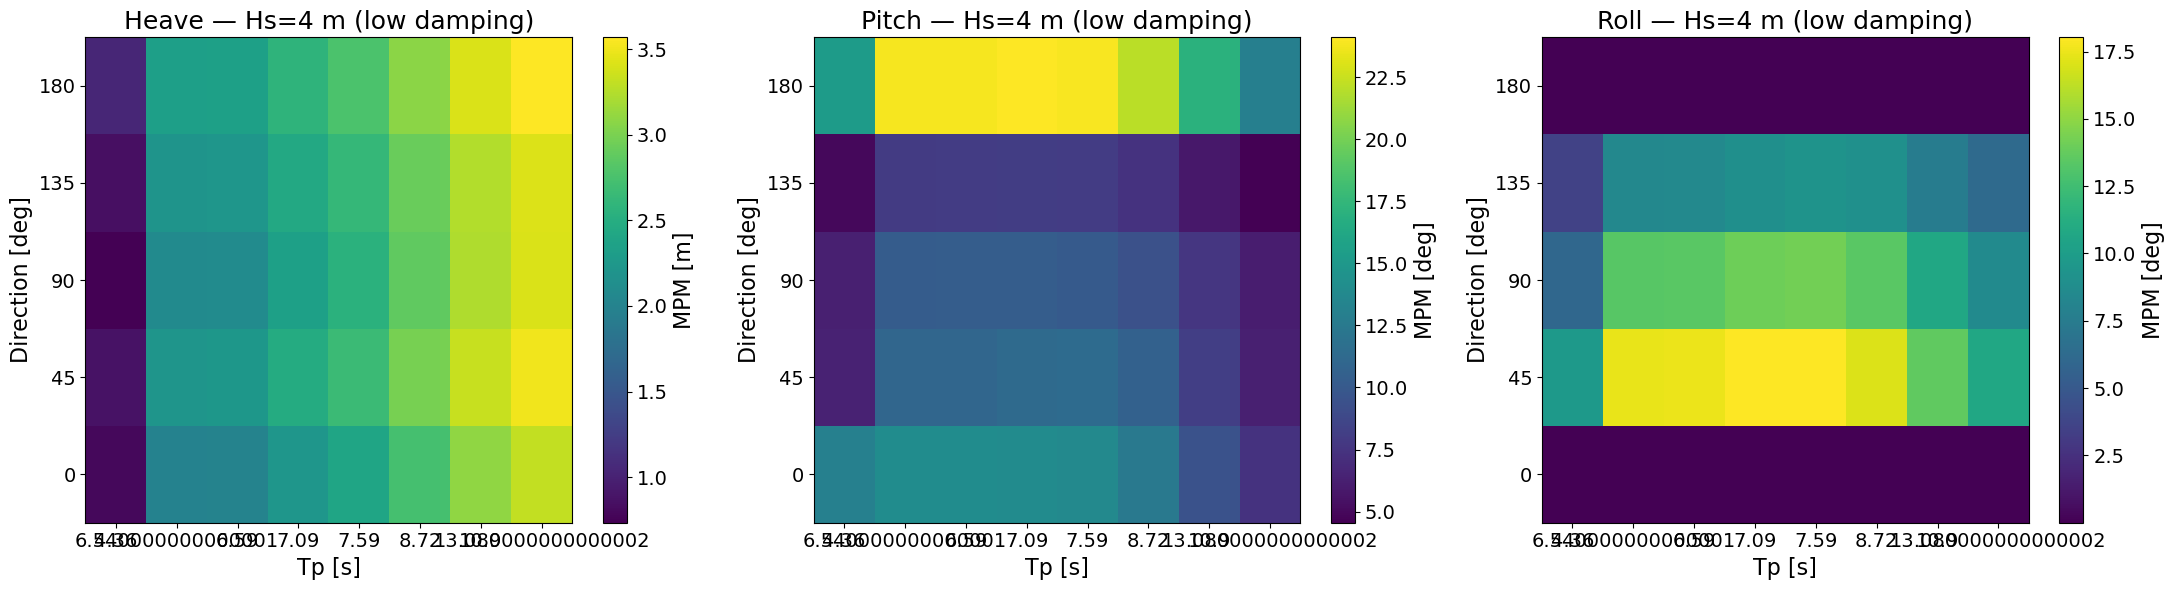

In [ ]:
for hs in HS_VALUES:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]  # baseline damping
    for ax, dof in zip(axes, DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        mpm_col = f'MPM {dof["key"]} corr'
        pivot = sub_dof.pivot_table(index='Direction', columns='Tp', values=mpm_col, aggfunc='mean')
        im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('Tp [s]')
        ax.set_ylabel('Direction [deg]')
        ax.set_title(f'{dof["name"]} — Hs={hs} m (low damping)')
        plt.colorbar(im, ax=ax, label=f'MPM [{dof["unit"]}]')
    fig.tight_layout()
plt.show()

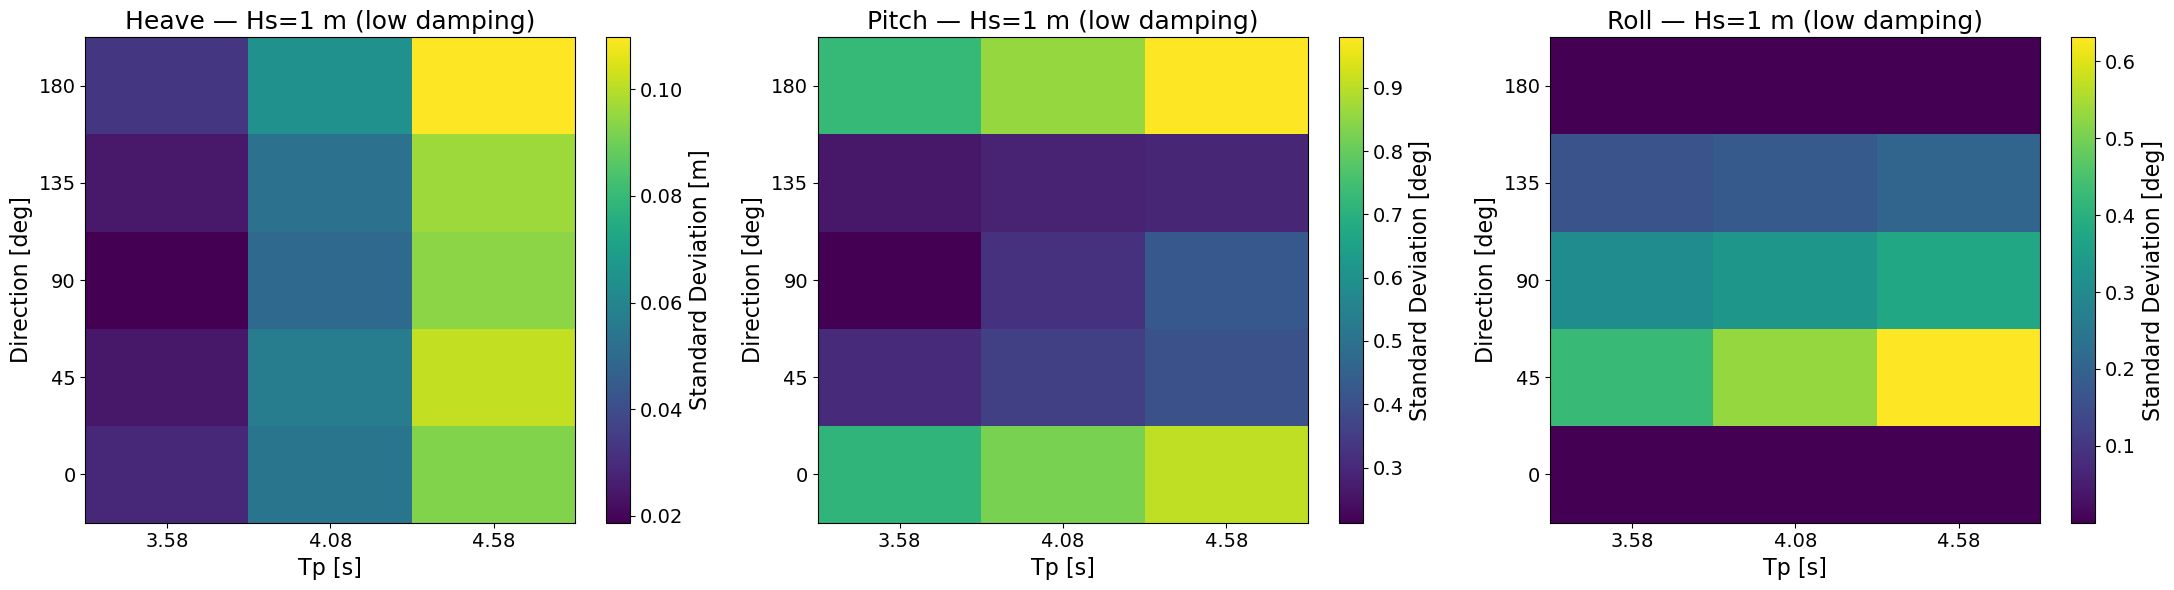

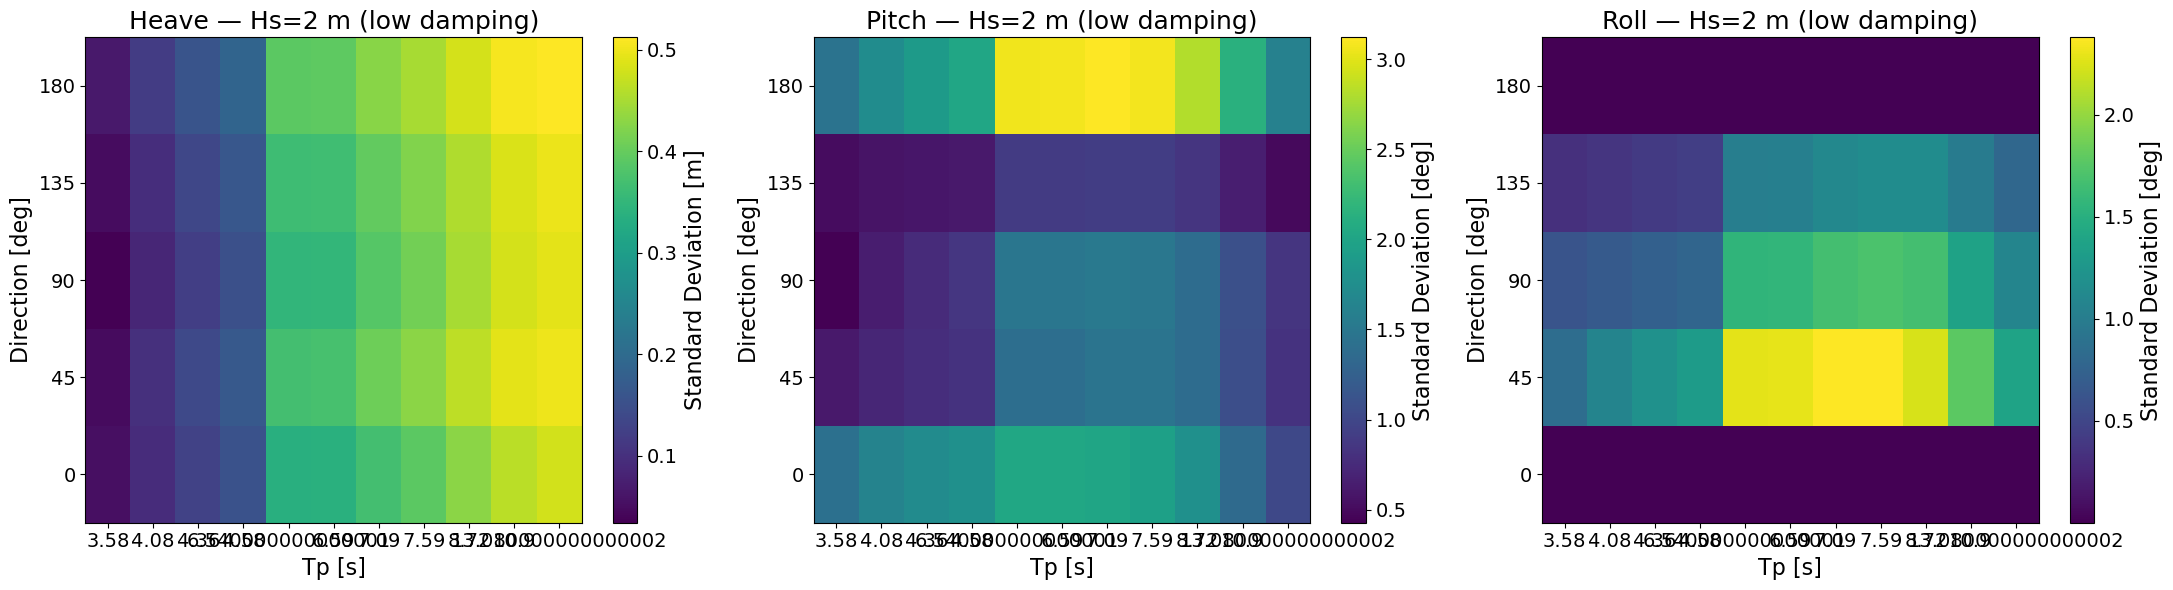

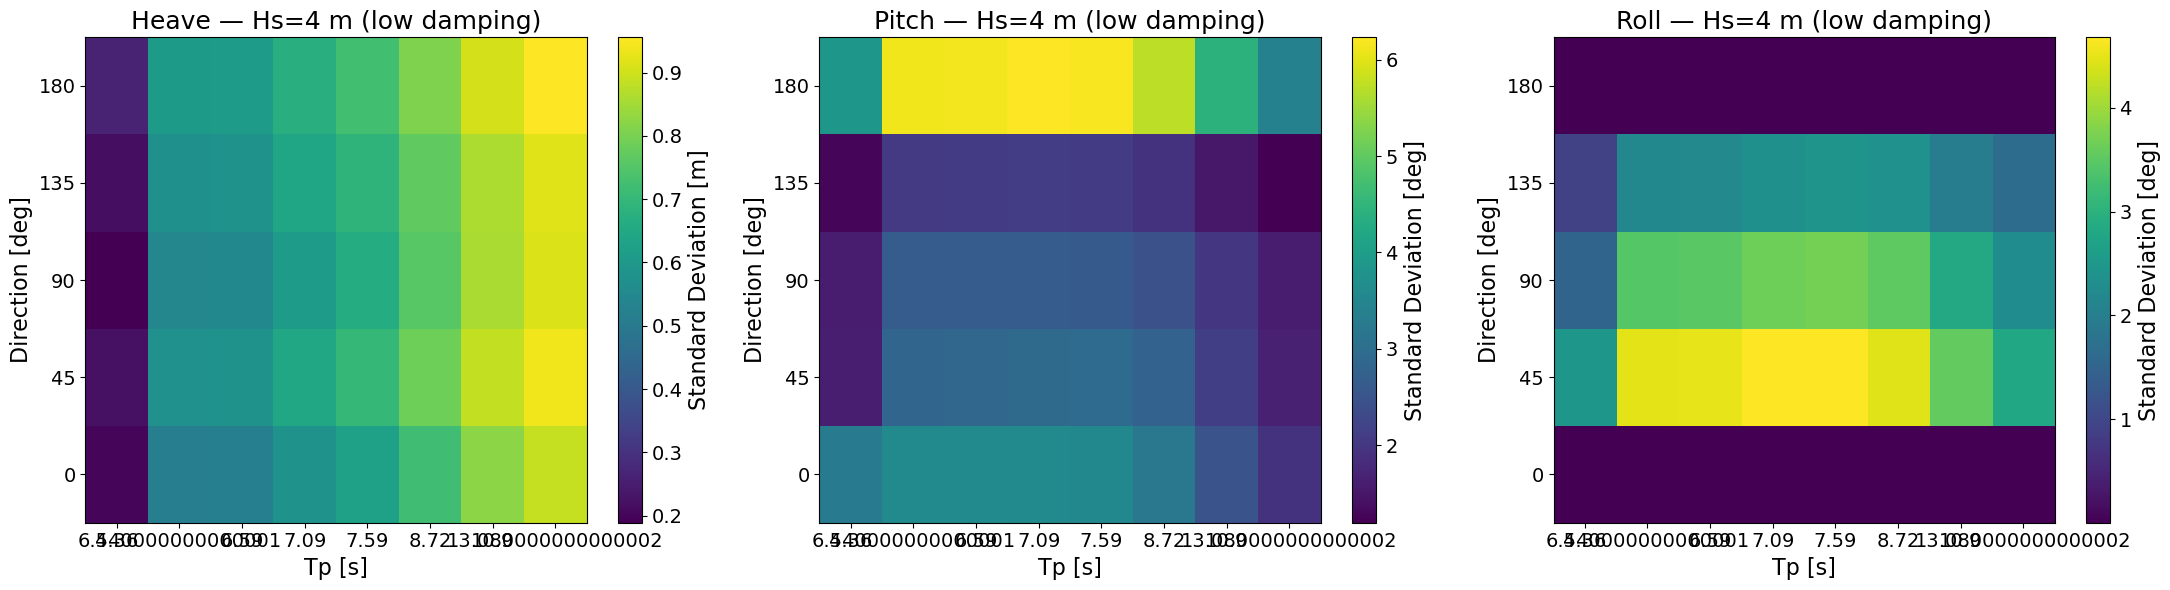

In [ ]:
for hs in HS_VALUES:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]  # baseline damping
    for ax, dof in zip(axes, DOFS):
        sub_dof = filter_dirs(sub_hs, dof)
        std_col = f'std {dof["key"]}'
        pivot = sub_dof.pivot_table(index='Direction', columns='Tp', values=std_col, aggfunc='mean')
        im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('Tp [s]')
        ax.set_ylabel('Direction [deg]')
        ax.set_title(f'{dof["name"]} — Hs={hs} m (low damping)')
        plt.colorbar(im, ax=ax, label=f'Standard Deviation [{dof["unit"]}]')
    fig.tight_layout()
plt.show()

## 6. Extra: MPM vs Std scatter, coloured by damping case

For a Gaussian process the MPM should be roughly proportional to the standard deviation (MPM ≈ k·σ with k around 3.7 for a 3-hour storm). Deviations from a straight line suggest non-Gaussian / non-linear behaviour.

## 7. Extra: worst case summary table per DOF and damping case

In [ ]:
rows = []
for dof in DOFS:
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_col = f'MPM {dof["key"]} corr'
    for case in DAMPING_CASES:
        sub_case = sub_dof[sub_dof[dcol] == case]
        if sub_case.empty:
            continue
        idx = sub_case[mpm_col].idxmax()
        row = sub_case.loc[idx]
        rows.append({
            'DOF': dof['name'],
            'Damping': case,
            'Hs': row['Hs'],
            'Tp': row['Tp'],
            'Direction': row['Direction'],
            'MPM corrected': row[mpm_col],
            'Std': row[f'std {dof["key"]}'],
        })

summary = pd.DataFrame(rows)
summary

,DOF,Damping,Hs,Tp,Direction,MPM corrected,Std
0,Heave,low,4,13.08,180,3.568126,0.955561
1,Heave,linhigh,4,13.08,180,3.521664,0.943693
2,Heave,quadhigh,4,13.08,180,3.547564,0.950247
3,Heave,average,4,13.08,180,3.539501,0.948152
4,Pitch,low,4,7.09,180,24.099145,6.233412
5,Pitch,linhigh,4,7.09,180,22.870025,5.912132
6,Pitch,quadhigh,4,7.09,180,22.831618,5.902871
7,Pitch,average,4,7.09,180,22.903815,5.921313
8,Roll,low,4,7.59,45,18.026182,4.681343
9,Roll,linhigh,4,7.59,45,16.978142,4.406671
